# Preparación de Datos — Siniestros Viales, Municipio de Envigado

**Fuente:** Datos Abiertos Colombia — Accidentalidad Municipio de Envigado
**Variable objetivo:** `GRAVEDAD` — se modela como problema de **clasificación binaria** (SOLO DAÑOS / HERIDOS); la clase MUERTOS se descarta en el paso 8
**Registros:** > 43.000 siniestros únicos · **Variables predictoras finales:** 8

Fases desarrolladas:
1. Integración de los datos
2. Eliminar variables irrelevantes/redundantes
3. Descripción estadística de los datos
4. Limpieza de datos atípicos
5. Limpieza de datos nulos
6. Análisis de correlaciones para redundancias
7. Análisis de correlaciones para irrelevancias
8. Balanceo de datos
9. Transformaciones (discretización / normalización)
10. Guardar los datos preparados
11. Modelos de clasificación con hiperparametrización (GridSearchCV + validación cruzada)

In [ ]:
# Importamos librerías básicas
import pandas as pd            # manipulación de dataframes
import numpy as np             # matrices y vectores
import matplotlib.pyplot as plt  # gráficas
import seaborn as sns          # mapas de calor / gráficas estadísticas
%matplotlib inline

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

# 1. Integración de los datos

El dataset proviene de una única fuente (portal de datos abiertos), pero **no está integrado de forma homogénea**:
- El mismo siniestro (`RADICADO`) aparece repetido varias veces (una fila por cada vehículo/actor involucrado), por lo que no hay una fila = un accidente.
- Las columnas `FECHA` y `HORA` combinan **dos formatos distintos** dentro de la misma columna (probablemente por venir de dos exportaciones/sistemas distintos que se concatenaron en un mismo archivo). Esto es exactamente un problema de *integración de datos*: hay que reconciliar los formatos antes de poder usarlos.

Resolvemos ambos problemas en esta fase.

In [ ]:
# Cargamos los datos
data = pd.read_csv("Accidentalidad_Municipio_de__Envigado_20260929.csv", low_memory=False)
print("Filas x Columnas:", data.shape)
data.head()

Filas x Columnas: (89826, 17)


,RADICADO,FECHA,HORA,DÍA DE LA SEMANA,CLASE DE VEHICULO,TIPO DE SERVICIO,TIPO DE VICTIMA,SEXO,ESTADO DE BEODEZ,RESULTADO DE BEODEZ,GRAVEDAD,CLASE DE ACCIDENTE,CAUSA,DIRECCIÓN,BARRIO,AREA,Coordenadas
0,2134024,1/01/2014,10:30:00 p. m.,Miércoles,NaN,NaN,NaN,NaN,0,0,SOLO DAÑOS,CHOQUE,Otra-Conductor,NaN,LAS FLORES,URBANA,POINT (-75.57921612 6.172014741)
1,2134024,1/01/2014,10:30:00 p. m.,Miércoles,NaN,NaN,NaN,NaN,0,0,HERIDOS,CHOQUE,Otra-Conductor,NaN,LAS FLORES,URBANA,POINT (-75.57921612 6.172014741)
2,2134026,1/01/2014,11:30:00 p. m.,Miércoles,NaN,NaN,NaN,NaN,0,0,HERIDOS,CHOQUE,Desobedecer señales,NaN,LAS VEGAS,URBANA,POINT (-75.60353748 6.162050378)
3,2134026,1/01/2014,11:30:00 p. m.,Miércoles,NaN,NaN,NaN,NaN,0,0,HERIDOS,CHOQUE,Desobedecer señales,NaN,LAS VEGAS,URBANA,POINT (-75.60353748 6.162050378)
4,2134026,1/01/2014,11:30:00 p. m.,Miércoles,NaN,NaN,NaN,NaN,0,0,SOLO DAÑOS,CHOQUE,Desobedecer señales,NaN,LAS VEGAS,URBANA,POINT (-75.60353748 6.162050378)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89826 entries, 0 to 89825
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   RADICADO             89826 non-null  int64 
 1   FECHA                89826 non-null  object
 2   HORA                 89826 non-null  object
 3   DÍA DE LA SEMANA     89826 non-null  object
 4   CLASE DE VEHICULO    390 non-null    object
 5   TIPO DE SERVICIO     390 non-null    object
 6   TIPO DE VICTIMA      81 non-null     object
 7   SEXO                 81 non-null     object
 8   ESTADO DE BEODEZ     89826 non-null  int64 
 9   RESULTADO DE BEODEZ  89826 non-null  int64 
 10  GRAVEDAD             89826 non-null  object
 11  CLASE DE ACCIDENTE   89826 non-null  object
 12  CAUSA                89826 non-null  object
 13  DIRECCIÓN            1459 non-null   object
 14  BARRIO               89826 non-null  object
 15  AREA                 89826 non-null  object
 16  Coor

## 1.1 Un accidente = varias filas (una por vehículo/persona involucrada)

Revisamos cuántas veces se repite cada `RADICADO` (identificador del siniestro).

In [ ]:
# Revisamos si tenemos RADICADOS repetidos
ids = data['RADICADO'].value_counts()
print("RADICADOS únicos:", data['RADICADO'].nunique(), "de", len(data), "filas")
ids[ids > 1].head()

RADICADOS únicos: 43759 de 89826 filas


,count
RADICADO,
2190880,24
2102365,17
2200919,15
2201176,12
2201642,11


In [ ]:
# Consolidamos: un siniestro = un registro. Nos quedamos con la versión más reciente de cada RADICADO
data.drop_duplicates(subset=['RADICADO'], keep='last', inplace=True)
print("Shape tras consolidar por RADICADO:", data.shape)

Shape tras consolidar por RADICADO: (43759, 17)


In [ ]:
# Verificamos que ya no hay RADICADOS repetidos
ids = data['RADICADO'].value_counts()
ids[ids > 1]

,count
RADICADO,


## 1.2 `FECHA` y `HORA`: formatos mixtos

Al inspeccionar `FECHA` encontramos registros como `'1/01/2014'` (texto `DD/MM/AAAA`) mezclados con `'2022-06-22T00:00:00.000'` (formato ISO). Pandas puede resolver esto con `format='mixed'`.

`HORA` es más problemático: mezcla un formato de texto en español ("10:30:00 p. m.") con un formato tipo fecha-Excel ("1899-12-31T14:30:00.000", donde 1899-12-31 es la fecha "cero" de Excel al exportar solo la hora). Escribimos una función que reconoce cada patrón y devuelve la hora correcta en ambos casos.

In [ ]:
# Ejemplo de los dos formatos que conviven en FECHA
print("Formato 1:", data['FECHA'].iloc[0])
print("Formato 2:", data.loc[data['FECHA'].str.startswith('2022'), 'FECHA'].iloc[0])

# Ejemplo de los dos formatos que conviven en HORA
print("\nFormato 1 (texto AM/PM):", data.loc[~data['HORA'].str.startswith('1899'), 'HORA'].iloc[0])
print("Formato 2 (pseudo-fecha Excel):", data.loc[data['HORA'].str.startswith('1899'), 'HORA'].iloc[0])

Formato 1: 1/01/2014
Formato 2: 2022-01-01T00:00:00.000

Formato 1 (texto AM/PM): 10:30:00 p. m.
Formato 2 (pseudo-fecha Excel): 1899-12-31T00:40:00.000


In [ ]:
# FECHA: pandas reconoce ambos formatos automáticamente con format='mixed'
data['FECHA'] = pd.to_datetime(data['FECHA'], format='mixed', dayfirst=True)
data['AÑO'] = data['FECHA'].dt.year
data['MES'] = data['FECHA'].dt.month
print(data['FECHA'].min(), "→", data['FECHA'].max())

2010-01-01 00:00:00 → 2022-06-22 00:00:00


In [ ]:
# HORA: función que reconcilia los dos formatos y devuelve la hora del día (0-23)
def parse_hora(valor):
    valor = str(valor)
    if valor.startswith('1899-12-31'):          # formato pseudo-fecha de Excel
        return pd.to_datetime(valor, errors='coerce')
    else:                                        # formato texto en español "hh:mm:ss a./p. m."
        valor_en = valor.replace('a. m.', 'AM').replace('p. m.', 'PM')
        return pd.to_datetime(valor_en, format='%I:%M:%S %p', errors='coerce')

data['HORA_DIA'] = data['HORA'].apply(parse_hora).dt.hour
print("Registros sin poder interpretar la hora:", data['HORA_DIA'].isna().sum())
data['HORA_DIA'].describe()

Registros sin poder interpretar la hora: 0


,HORA_DIA
count,43759.000000
mean,13.240453
std,5.005390
min,0.000000
25%,9.000000
50%,14.000000
75%,17.000000
max,23.000000


**Resultado de la integración:** los 89.826 registros originales correspondían a 43.759 siniestros únicos. `FECHA` y `HORA` quedaron unificadas en columnas consistentes (`AÑO`, `MES`, `HORA_DIA`) sin ningún valor sin interpretar (0 fallos de parseo).

In [ ]:
# Ajustamos tipos de dato: categorías para las variables categóricas
# (CAUSA y BARRIO se dejan como texto por ahora: se agrupan en el paso 2 antes de tipificarlas)
for col in ['DÍA DE LA SEMANA', 'ESTADO DE BEODEZ', 'GRAVEDAD', 'CLASE DE ACCIDENTE',
            'AREA', 'AÑO', 'MES']:
    data[col] = data[col].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43759 entries, 1 to 89825
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   RADICADO             43759 non-null  int64         
 1   FECHA                43759 non-null  datetime64[ns]
 2   HORA                 43759 non-null  object        
 3   DÍA DE LA SEMANA     43759 non-null  category      
 4   CLASE DE VEHICULO    196 non-null    object        
 5   TIPO DE SERVICIO     196 non-null    object        
 6   TIPO DE VICTIMA      45 non-null     object        
 7   SEXO                 45 non-null     object        
 8   ESTADO DE BEODEZ     43759 non-null  category      
 9   RESULTADO DE BEODEZ  43759 non-null  int64         
 10  GRAVEDAD             43759 non-null  category      
 11  CLASE DE ACCIDENTE   43759 non-null  category      
 12  CAUSA                43759 non-null  object        
 13  DIRECCIÓN            747 non-null   

# 2. Eliminar variables irrelevantes y redundantes

**Criterio:**
- *Irrelevantes*: identificadores, texto libre, o columnas con datos insuficientes para aportar señal.
- *Redundantes*: columnas que quedaron duplicadas por una transformación matemática (p. ej. `FECHA`/`HORA` ya se descompusieron en `AÑO`, `MES`, `HORA_DIA`).

Primero revisamos el % de nulos de cada columna, porque varias columnas son candidatas a eliminarse por falta casi total de datos.

In [ ]:
nulos_pct = (data.isnull().sum() / len(data) * 100).round(2).sort_values(ascending=False)
nulos_pct

,0
TIPO DE VICTIMA,99.90
SEXO,99.90
CLASE DE VEHICULO,99.55
TIPO DE SERVICIO,99.55
DIRECCIÓN,98.29
Coordenadas,74.14
FECHA,0.00
RADICADO,0.00
DÍA DE LA SEMANA,0.00
HORA,0.00


Cuatro columnas (`CLASE DE VEHICULO`, `TIPO DE SERVICIO`, `TIPO DE VICTIMA`, `SEXO`) tienen más del 99% de nulos: prácticamente no tienen información y no aportan como variables predictoras. `DIRECCIÓN` (98%) y `Coordenadas` (75%) también superan ampliamente el umbral de nulos manejable y, además, son identificadores de ubicación / texto libre, no variables analíticas directas. Las eliminamos por **irrelevantes**.

`RADICADO` es un identificador (ya cumplió su función para deduplicar) y `FECHA`/`HORA` quedaron **redundantes** frente a `AÑO`, `MES`, `HORA_DIA` que ya calculamos.

In [ ]:
# Variables irrelevantes (identificador, texto libre, o >75% de nulos)
irrelevantes = ['RADICADO', 'DIRECCIÓN', 'Coordenadas',
                 'CLASE DE VEHICULO', 'TIPO DE SERVICIO', 'TIPO DE VICTIMA', 'SEXO']
data.drop(columns=irrelevantes, inplace=True)

# Variables redundantes: ya extrajimos toda su información en AÑO, MES, HORA_DIA
redundantes = ['FECHA', 'HORA']
data.drop(columns=redundantes, inplace=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43759 entries, 1 to 89825
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   DÍA DE LA SEMANA     43759 non-null  category
 1   ESTADO DE BEODEZ     43759 non-null  category
 2   RESULTADO DE BEODEZ  43759 non-null  int64   
 3   GRAVEDAD             43759 non-null  category
 4   CLASE DE ACCIDENTE   43759 non-null  category
 5   CAUSA                43759 non-null  object  
 6   BARRIO               43759 non-null  object  
 7   AREA                 43759 non-null  category
 8   AÑO                  43759 non-null  category
 9   MES                  43759 non-null  category
 10  HORA_DIA             43759 non-null  int32   
dtypes: category(7), int32(1), int64(1), object(2)
memory usage: 1.8+ MB


## 2.1 Reducción de cardinalidad en `CAUSA` y `BARRIO`

`CAUSA` tiene 405 categorías distintas y `BARRIO` 49. Con esa cardinalidad, la mayoría de categorías tienen muy pocos registros (ruido estadístico) y, al convertirlas en variables *dummy* más adelante, generarían cientos de columnas casi vacías. Agrupamos cada variable en sus categorías más frecuentes + una categoría `OTRA(O)` para el resto — así conservamos el patrón dominante sin la dispersión.

In [ ]:
print("CAUSA - categorías únicas:", data['CAUSA'].nunique())
print("BARRIO - categorías únicas:", data['BARRIO'].nunique())

# Cuánto explican las 15 categorías más frecuentes de cada una
top_causas_pct = data['CAUSA'].value_counts(normalize=True).nlargest(15).sum() * 100
top_barrios_pct = data['BARRIO'].value_counts(normalize=True).nlargest(15).sum() * 100
print(f"\nLas 15 causas más frecuentes explican el {top_causas_pct:.1f}% de los registros")
print(f"Los 15 barrios más frecuentes explican el {top_barrios_pct:.1f}% de los registros")

CAUSA - categorías únicas: 405
BARRIO - categorías únicas: 49

Las 15 causas más frecuentes explican el 88.6% de los registros
Los 15 barrios más frecuentes explican el 78.1% de los registros


In [ ]:
# CAUSA -> top 15 + 'OTRA' (conservamos NaN donde ya era NaN)
top_causas = data['CAUSA'].value_counts().nlargest(15).index
data['CAUSA_AGRUPADA'] = data['CAUSA'].where(data['CAUSA'].isin(top_causas), other='OTRA')

# BARRIO -> top 15 + 'OTRO'
top_barrios = data['BARRIO'].value_counts().nlargest(15).index
data['BARRIO_AGRUPADO'] = data['BARRIO'].where(data['BARRIO'].isin(top_barrios), other='OTRO')

data.drop(columns=['CAUSA', 'BARRIO'], inplace=True)  # quedan reemplazadas por las agrupadas
data['CAUSA_AGRUPADA'] = data['CAUSA_AGRUPADA'].astype('category')
data['BARRIO_AGRUPADO'] = data['BARRIO_AGRUPADO'].astype('category')
print("CAUSA_AGRUPADA:", data['CAUSA_AGRUPADA'].nunique(), "categorías")
print("BARRIO_AGRUPADO:", data['BARRIO_AGRUPADO'].nunique(), "categorías")

CAUSA_AGRUPADA: 16 categorías
BARRIO_AGRUPADO: 16 categorías


In [ ]:
data.head()

,DÍA DE LA SEMANA,ESTADO DE BEODEZ,RESULTADO DE BEODEZ,GRAVEDAD,CLASE DE ACCIDENTE,AREA,AÑO,MES,HORA_DIA,CAUSA_AGRUPADA,BARRIO_AGRUPADO
1,Miércoles,0,0,HERIDOS,CHOQUE,URBANA,2014,1,22,Otra-Conductor,OTRO
4,Miércoles,0,0,SOLO DAÑOS,CHOQUE,URBANA,2014,1,23,Desobedecer señales,LAS VEGAS
5,Miércoles,0,0,HERIDOS,ATROPELLO,URBANA,2014,1,21,Otra-Conductor,LAS VEGAS
7,Miércoles,0,0,HERIDOS,CHOQUE,URBANA,2014,1,19,Otra-Conductor,OTRO
9,Jueves,0,0,SOLO DAÑOS,CHOQUE,URBANA,2014,1,19,Otra-Conductor,OTRO


**Resultado:** partimos de 17 columnas originales. Tras eliminar 7 irrelevantes y 2 redundantes, y reemplazar `CAUSA`/`BARRIO` por sus versiones agrupadas, quedamos con **10 variables** (incluida la variable objetivo `GRAVEDAD`), todas con información útil y con cardinalidad manejable.

# 3. Descripción estadística de los datos

**Variables numéricas**

In [ ]:
data.describe()

,RESULTADO DE BEODEZ,HORA_DIA
count,43759.000000,43759.000000
mean,0.006696,13.240453
std,0.124938,5.005390
min,0.000000,0.000000
25%,0.000000,9.000000
50%,0.000000,14.000000
75%,0.000000,17.000000
max,3.000000,23.000000


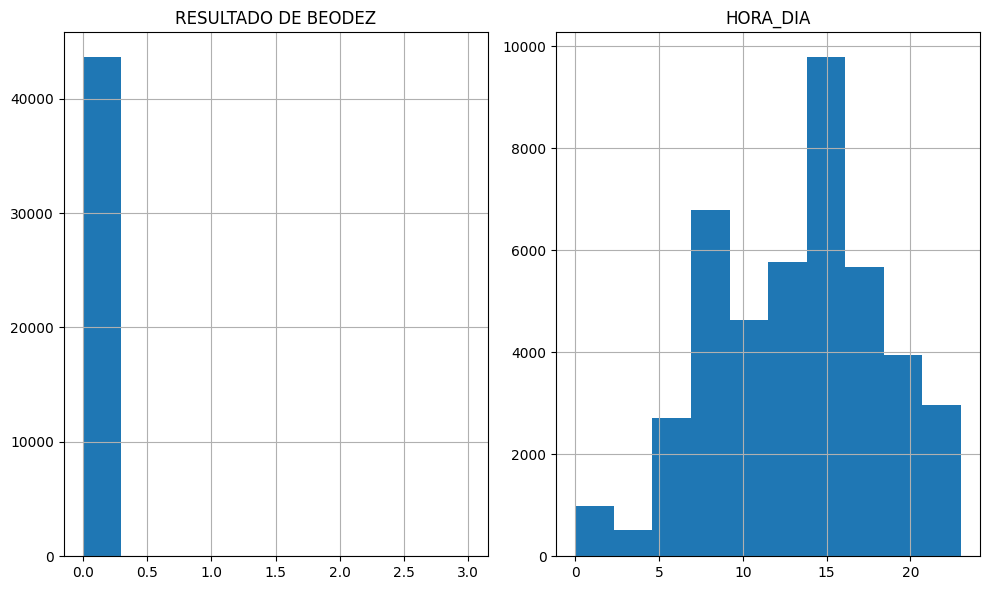

In [ ]:
# Histogramas
data.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

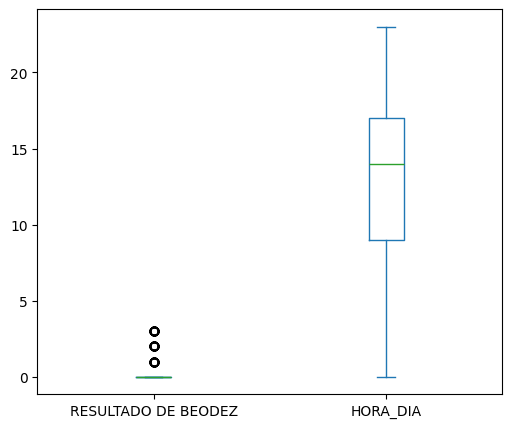

In [ ]:
# Boxplot conjunto de las numéricas
data.plot.box(figsize=(6, 5))
plt.show()

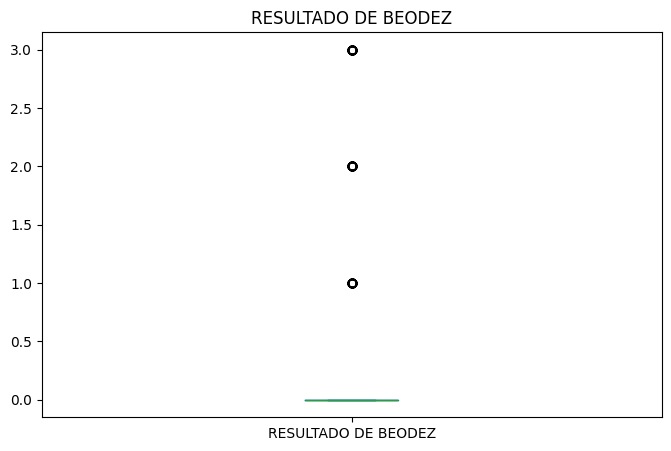

In [ ]:
data['RESULTADO DE BEODEZ'].plot.box()
plt.title('RESULTADO DE BEODEZ')
plt.show()

**Variables categóricas** (`value_counts()`)

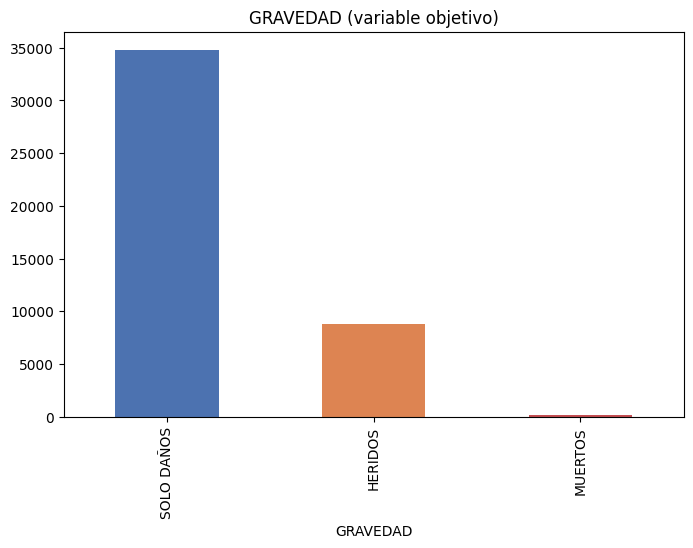

,proportion
GRAVEDAD,
SOLO DAÑOS,79.5
HERIDOS,20.2
MUERTOS,0.3


In [ ]:
data['GRAVEDAD'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#C44E52'])
plt.title('GRAVEDAD (variable objetivo)')
plt.show()
data['GRAVEDAD'].value_counts(normalize=True).round(3) * 100

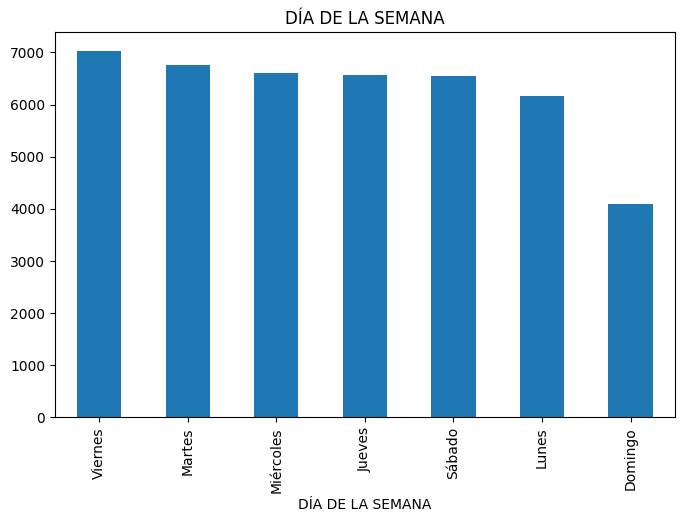

In [ ]:
data['DÍA DE LA SEMANA'].value_counts().plot(kind='bar')
plt.title('DÍA DE LA SEMANA')
plt.show()

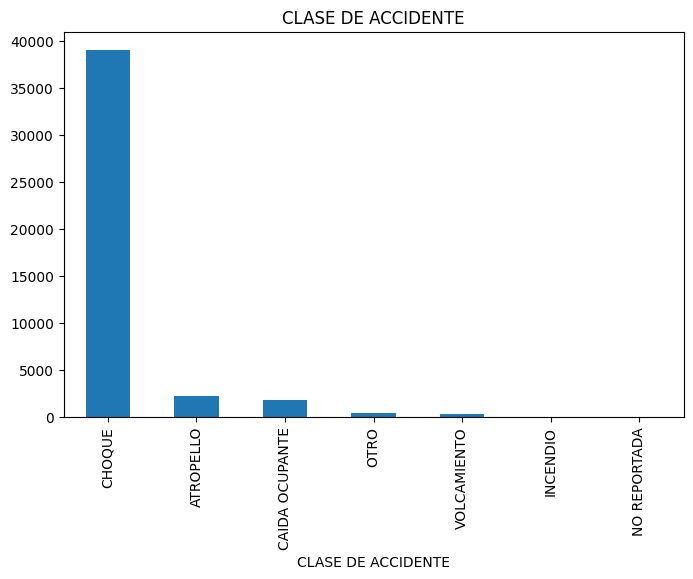

In [ ]:
data['CLASE DE ACCIDENTE'].value_counts().plot(kind='bar')
plt.title('CLASE DE ACCIDENTE')
plt.show()

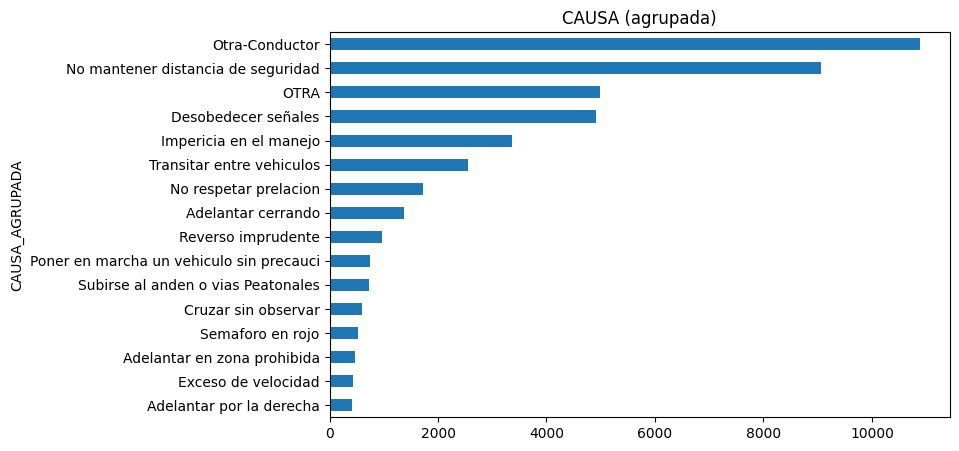

In [ ]:
data['CAUSA_AGRUPADA'].value_counts().plot(kind='barh')
plt.title('CAUSA (agrupada)')
plt.gca().invert_yaxis()
plt.show()

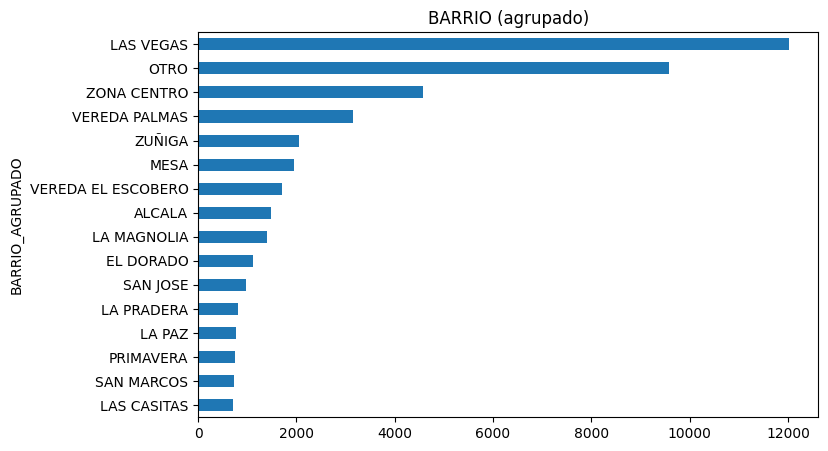

In [ ]:
data['BARRIO_AGRUPADO'].value_counts().plot(kind='barh')
plt.title('BARRIO (agrupado)')
plt.gca().invert_yaxis()
plt.show()

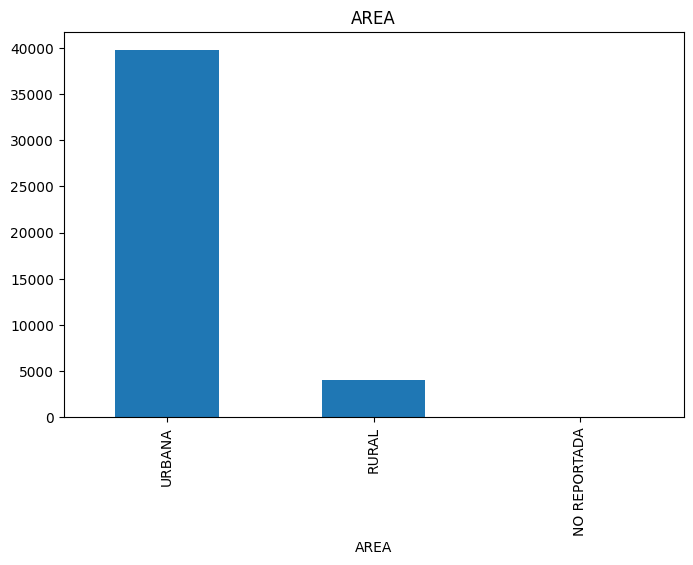

In [ ]:
data['AREA'].value_counts().plot(kind='bar')
plt.title('AREA')
plt.show()

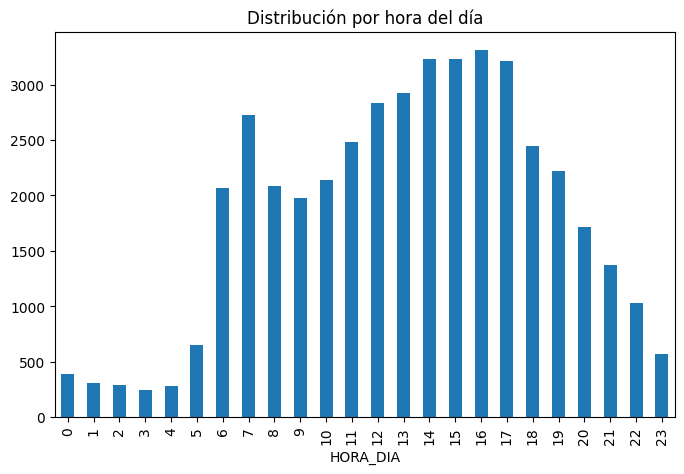

In [ ]:
data['HORA_DIA'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución por hora del día')
plt.show()

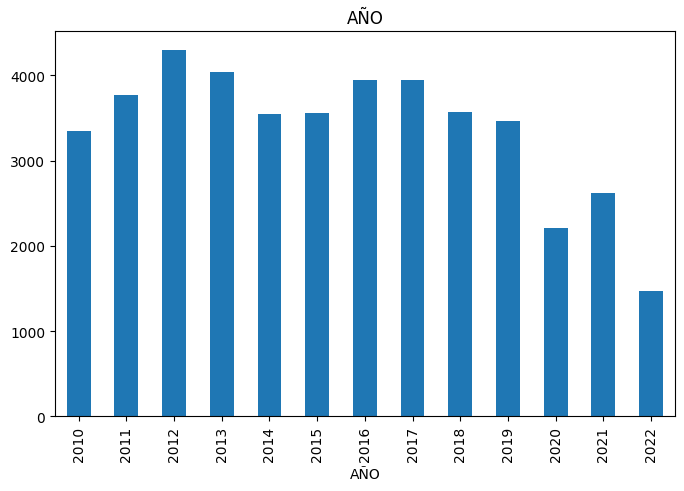

In [ ]:
data['AÑO'].value_counts().sort_index().plot(kind='bar')
plt.title('AÑO')
plt.show()

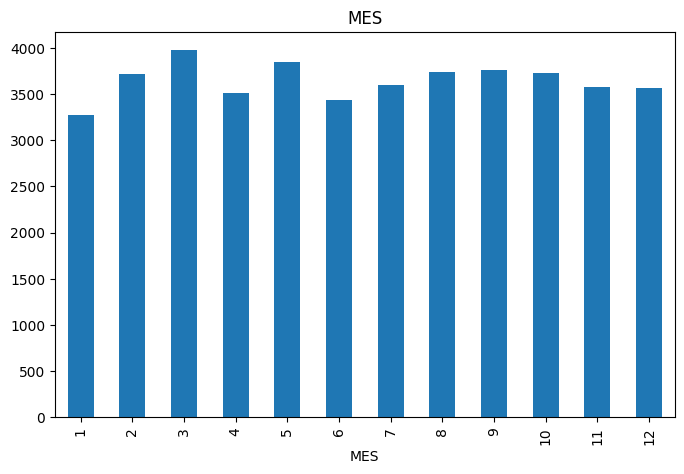

In [ ]:
data['MES'].value_counts().sort_index().plot(kind='bar')
plt.title('MES')
plt.show()

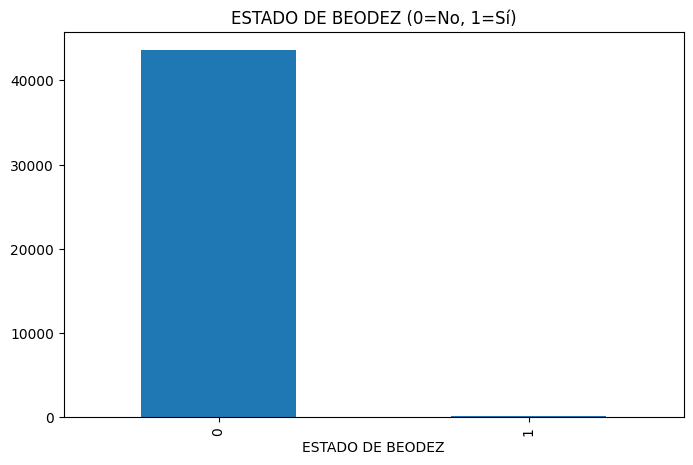

In [ ]:
data['ESTADO DE BEODEZ'].value_counts().plot(kind='bar')
plt.title('ESTADO DE BEODEZ (0=No, 1=Sí)')
plt.show()

**Gráfica de relaciones entre variables numéricas**

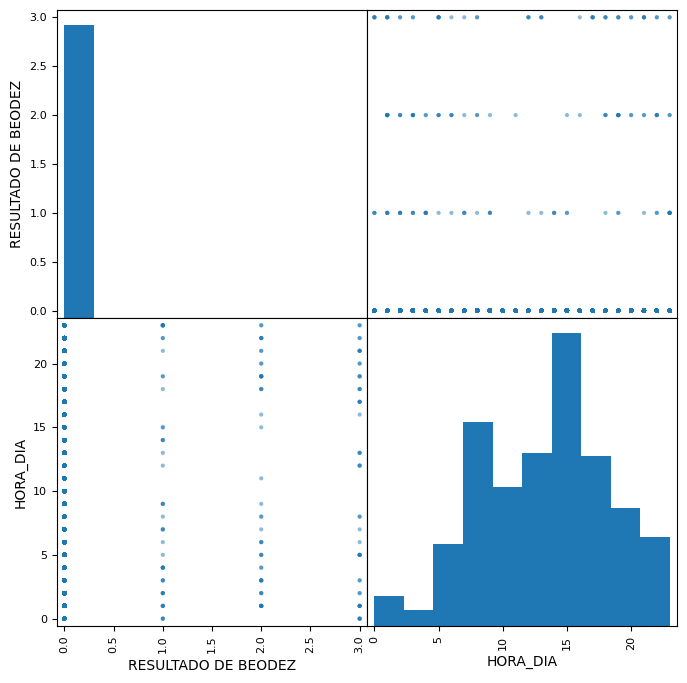

In [ ]:
pd.plotting.scatter_matrix(data[['ESTADO DE BEODEZ', 'RESULTADO DE BEODEZ', 'HORA_DIA']], figsize=(8, 8))
plt.show()

**Perfilado de datos**

In [ ]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
profile_data = ProfileReport(data, minimal=True, title="Perfilado - Siniestros Viales Envigado")
profile_data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.5 MB/s eta 0:00:00


/tmp/ipykernel_9300/3787986479.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 56.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Guardamos el perfilado en HTML (entregable del taller)
profile_data.to_file(output_file="perfilado_siniestros_viales_envigado.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Dimensiones de la calidad de datos

- **Completitud:** buena en las variables que conservamos; los nulos reales detectados son mínimos (<0.01%) una vez descartadas las columnas casi vacías (`CLASE DE VEHICULO`, `TIPO DE SERVICIO`, `TIPO DE VICTIMA`, `SEXO`, ya eliminadas en el paso 2).
- **Exactitud:** aceptable; no se detectan valores fuera de rango en las variables numéricas (`ESTADO DE BEODEZ` ∈ {0,1}, `RESULTADO DE BEODEZ` ∈ {0,1,2,3}).
- **Conformidad:** baja en el formato crudo de `FECHA`/`HORA` (dos formatos distintos conviviendo en la misma columna); ya resuelta en el paso 1.
- **Unicidad:** el archivo original no era único a nivel de accidente (46.067 filas duplicadas por `RADICADO`); resuelto en el paso 1.
- **Actualidad:** los datos cubren 2010–2022; no se puede verificar qué tan actualizado está el proceso de captura sin metadatos adicionales del portal.
- **Consistencia:** algunos valores tipo "NO REPORTADA"/"NO REPORTA" funcionan como nulos disfrazados; se tratan en el paso 4.


# 4. Limpieza de datos atípicos (errores)

Aquí solo corregimos **errores** de captura, no valores extremos legítimos (p. ej. un mes con más accidentes que otros no es un error, es un patrón real). Verificamos:
1. Que las variables numéricas estén dentro de su rango válido.
2. Que no existan valores tipo "no reportado" escondidos como si fueran una categoría más (son en realidad datos faltantes).

In [ ]:
# 1) Rango válido de las variables numéricas/codificadas
print("ESTADO DE BEODEZ - valores:", sorted(data['ESTADO DE BEODEZ'].unique()))
print("RESULTADO DE BEODEZ - valores:", sorted(data['RESULTADO DE BEODEZ'].unique()))
print("HORA_DIA - rango:", data['HORA_DIA'].min(), "-", data['HORA_DIA'].max())
print("AÑO - rango:", data['AÑO'].astype(int).min(), "-", data['AÑO'].astype(int).max())
# Todos dentro de rangos esperados: no hay errores de captura en estas columnas.

ESTADO DE BEODEZ - valores: [0, 1]
RESULTADO DE BEODEZ - valores: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
HORA_DIA - rango: 0 - 23
AÑO - rango: 2010 - 2022


In [ ]:
# 2) Valores "no reportado" ocultos en variables categóricas
for col in ['CLASE DE ACCIDENTE', 'AREA', 'CAUSA_AGRUPADA', 'BARRIO_AGRUPADO']:
    encontrados = data[col].astype(str).str.upper().str.contains('NO REPORT', na=False)
    if encontrados.sum() > 0:
        print(f"{col}: {encontrados.sum()} registro(s) con valor 'no reportado'")

CLASE DE ACCIDENTE: 1 registro(s) con valor 'no reportado'
AREA: 4 registro(s) con valor 'no reportado'


In [ ]:
# Los tratamos como error de captura -> los convertimos a nulo (NaN) para tratarlos en el paso 5
data['CLASE DE ACCIDENTE'] = data['CLASE DE ACCIDENTE'].astype(str).replace('NO REPORTADA', np.nan)
data['AREA'] = data['AREA'].astype(str).replace('NO REPORTADA', np.nan)
data['CAUSA_AGRUPADA'] = data['CAUSA_AGRUPADA'].astype(str).replace('NO REPORTA', np.nan)
data['BARRIO_AGRUPADO'] = data['BARRIO_AGRUPADO'].astype(str).replace('NO REPORTA', np.nan)

data.isnull().sum()

,0
DÍA DE LA SEMANA,0
ESTADO DE BEODEZ,0
RESULTADO DE BEODEZ,0
GRAVEDAD,0
CLASE DE ACCIDENTE,1
AREA,4
AÑO,0
MES,0
HORA_DIA,0
CAUSA_AGRUPADA,0


**Conclusión:** el dataset no tenía errores de rango en las variables numéricas. Los únicos errores encontrados fueron 5 registros (de 43.759, un 0,011%) con el valor placeholder "NO REPORTADA/NO REPORTA" en variables categóricas, que convertimos en nulos explícitos para imputarlos en el siguiente paso.

# 5. Limpieza de datos nulos: Imputación

**Estrategia:**
- Eliminar registros con más de 15% de nulos → no aplica (ningún registro tiene múltiples nulos).
- Eliminar columnas con más de 15-20% de nulos → ya se aplicó en el paso 2 (columnas con 99%+ de nulos).
- Imputar por moda las columnas categóricas restantes, dado que su % de nulos es mínimo.

In [ ]:
nulos_pct = (data.isnull().sum() / len(data) * 100).round(4)
nulos_pct[nulos_pct > 0]

,0
CLASE DE ACCIDENTE,0.0023
AREA,0.0091


In [ ]:
from sklearn.impute import SimpleImputer

cols_a_imputar = ['CLASE DE ACCIDENTE', 'AREA', 'CAUSA_AGRUPADA', 'BARRIO_AGRUPADO']
imputador = SimpleImputer(strategy='most_frequent')
data[cols_a_imputar] = imputador.fit_transform(data[cols_a_imputar])

print("Valor de la imputación (moda) por variable:")
for col, valor in zip(cols_a_imputar, imputador.statistics_):
    print(f"  {col}: '{valor}'")

Valor de la imputación (moda) por variable:
  CLASE DE ACCIDENTE: 'CHOQUE'
  AREA: 'URBANA'
  CAUSA_AGRUPADA: 'Otra-Conductor'
  BARRIO_AGRUPADO: 'LAS VEGAS'


In [ ]:
print("Nulos restantes en todo el dataset:", data.isnull().sum().sum())

# Recuperamos el tipo categórico (SimpleImputer devuelve texto)
for col in ['DÍA DE LA SEMANA', 'ESTADO DE BEODEZ', 'GRAVEDAD', 'CLASE DE ACCIDENTE',
            'CAUSA_AGRUPADA', 'BARRIO_AGRUPADO', 'AREA', 'AÑO', 'MES']:
    data[col] = data[col].astype('category')

data.info()

Nulos restantes en todo el dataset: 0
<class 'pandas.core.frame.DataFrame'>
Index: 43759 entries, 1 to 89825
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   DÍA DE LA SEMANA     43759 non-null  category
 1   ESTADO DE BEODEZ     43759 non-null  category
 2   RESULTADO DE BEODEZ  43759 non-null  int64   
 3   GRAVEDAD             43759 non-null  category
 4   CLASE DE ACCIDENTE   43759 non-null  category
 5   AREA                 43759 non-null  category
 6   AÑO                  43759 non-null  category
 7   MES                  43759 non-null  category
 8   HORA_DIA             43759 non-null  int32   
 9   CAUSA_AGRUPADA       43759 non-null  category
 10  BARRIO_AGRUPADO      43759 non-null  category
dtypes: category(9), int32(1), int64(1)
memory usage: 1.2 MB


# 6. Correlaciones para redundancias

**Redundancia = correlación mayor a |0.8|.** Para calcular correlaciones todas las variables deben ser numéricas, así que generamos *dummies* de las categóricas (solo para este análisis; el dataset de trabajo `data` no se modifica todavía).

In [ ]:
cat_cols = ['DÍA DE LA SEMANA', 'CLASE DE ACCIDENTE', 'AÑO', 'MES',
            'CAUSA_AGRUPADA', 'BARRIO_AGRUPADO', 'GRAVEDAD']
data_num = pd.get_dummies(data, columns=cat_cols, drop_first=False, dtype=int)

# Área terminó como binaria porque se le imputaron la categoría de nulos (Ver 4 y 5)
# Estado de Beodez es binaria desde el principio
data_num = pd.get_dummies(data_num, columns=['AREA', 'ESTADO DE BEODEZ'], drop_first=True, dtype=int)
data_num.head()

,RESULTADO DE BEODEZ,HORA_DIA,DÍA DE LA SEMANA_Domingo,DÍA DE LA SEMANA_Jueves,DÍA DE LA SEMANA_Lunes,DÍA DE LA SEMANA_Martes,DÍA DE LA SEMANA_Miércoles,DÍA DE LA SEMANA_Sábado,DÍA DE LA SEMANA_Viernes,CLASE DE ACCIDENTE_ATROPELLO,CLASE DE ACCIDENTE_CAIDA OCUPANTE,CLASE DE ACCIDENTE_CHOQUE,CLASE DE ACCIDENTE_INCENDIO,CLASE DE ACCIDENTE_OTRO,CLASE DE ACCIDENTE_VOLCAMIENTO,AÑO_2010,AÑO_2011,AÑO_2012,AÑO_2013,AÑO_2014,AÑO_2015,AÑO_2016,AÑO_2017,AÑO_2018,AÑO_2019,AÑO_2020,AÑO_2021,AÑO_2022,MES_1,MES_2,MES_3,MES_4,MES_5,MES_6,MES_7,MES_8,MES_9,MES_10,MES_11,MES_12,CAUSA_AGRUPADA_Adelantar cerrando,CAUSA_AGRUPADA_Adelantar en zona prohibida,CAUSA_AGRUPADA_Adelantar por la derecha,CAUSA_AGRUPADA_Cruzar sin observar,CAUSA_AGRUPADA_Desobedecer señales,CAUSA_AGRUPADA_Exceso de velocidad,CAUSA_AGRUPADA_Impericia en el manejo,CAUSA_AGRUPADA_No mantener distancia de seguridad,CAUSA_AGRUPADA_No respetar prelacion,CAUSA_AGRUPADA_OTRA,CAUSA_AGRUPADA_Otra-Conductor,CAUSA_AGRUPADA_Poner en marcha un vehiculo sin precauci,CAUSA_AGRUPADA_Reverso imprudente,CAUSA_AGRUPADA_Semaforo en rojo,CAUSA_AGRUPADA_Subirse al anden o vias Peatonales,CAUSA_AGRUPADA_Transitar entre vehiculos,BARRIO_AGRUPADO_ALCALA,BARRIO_AGRUPADO_EL DORADO,BARRIO_AGRUPADO_LA MAGNOLIA,BARRIO_AGRUPADO_LA PAZ,BARRIO_AGRUPADO_LA PRADERA,BARRIO_AGRUPADO_LAS CASITAS,BARRIO_AGRUPADO_LAS VEGAS,BARRIO_AGRUPADO_MESA,BARRIO_AGRUPADO_OTRO,BARRIO_AGRUPADO_PRIMAVERA,BARRIO_AGRUPADO_SAN JOSE,BARRIO_AGRUPADO_SAN MARCOS,BARRIO_AGRUPADO_VEREDA EL ESCOBERO,BARRIO_AGRUPADO_VEREDA PALMAS,BARRIO_AGRUPADO_ZONA CENTRO,BARRIO_AGRUPADO_ZUÑIGA,GRAVEDAD_HERIDOS,GRAVEDAD_MUERTOS,GRAVEDAD_SOLO DAÑOS,AREA_URBANA,ESTADO DE BEODEZ_1
1,0,22,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0,23,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0
5,0,21,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
7,0,19,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0
9,0,19,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0


In [ ]:
correlaciones = data_num.corr()
correlaciones

,RESULTADO DE BEODEZ,HORA_DIA,DÍA DE LA SEMANA_Domingo,DÍA DE LA SEMANA_Jueves,DÍA DE LA SEMANA_Lunes,DÍA DE LA SEMANA_Martes,DÍA DE LA SEMANA_Miércoles,DÍA DE LA SEMANA_Sábado,DÍA DE LA SEMANA_Viernes,CLASE DE ACCIDENTE_ATROPELLO,CLASE DE ACCIDENTE_CAIDA OCUPANTE,CLASE DE ACCIDENTE_CHOQUE,CLASE DE ACCIDENTE_INCENDIO,CLASE DE ACCIDENTE_OTRO,CLASE DE ACCIDENTE_VOLCAMIENTO,AÑO_2010,AÑO_2011,AÑO_2012,AÑO_2013,AÑO_2014,AÑO_2015,AÑO_2016,AÑO_2017,AÑO_2018,AÑO_2019,AÑO_2020,AÑO_2021,AÑO_2022,MES_1,MES_2,MES_3,MES_4,MES_5,MES_6,MES_7,MES_8,MES_9,MES_10,MES_11,MES_12,CAUSA_AGRUPADA_Adelantar cerrando,CAUSA_AGRUPADA_Adelantar en zona prohibida,CAUSA_AGRUPADA_Adelantar por la derecha,CAUSA_AGRUPADA_Cruzar sin observar,CAUSA_AGRUPADA_Desobedecer señales,CAUSA_AGRUPADA_Exceso de velocidad,CAUSA_AGRUPADA_Impericia en el manejo,CAUSA_AGRUPADA_No mantener distancia de seguridad,CAUSA_AGRUPADA_No respetar prelacion,CAUSA_AGRUPADA_OTRA,CAUSA_AGRUPADA_Otra-Conductor,CAUSA_AGRUPADA_Poner en marcha un vehiculo sin precauci,CAUSA_AGRUPADA_Reverso imprudente,CAUSA_AGRUPADA_Semaforo en rojo,CAUSA_AGRUPADA_Subirse al anden o vias Peatonales,CAUSA_AGRUPADA_Transitar entre vehiculos,BARRIO_AGRUPADO_ALCALA,BARRIO_AGRUPADO_EL DORADO,BARRIO_AGRUPADO_LA MAGNOLIA,BARRIO_AGRUPADO_LA PAZ,BARRIO_AGRUPADO_LA PRADERA,BARRIO_AGRUPADO_LAS CASITAS,BARRIO_AGRUPADO_LAS VEGAS,BARRIO_AGRUPADO_MESA,BARRIO_AGRUPADO_OTRO,BARRIO_AGRUPADO_PRIMAVERA,BARRIO_AGRUPADO_SAN JOSE,BARRIO_AGRUPADO_SAN MARCOS,BARRIO_AGRUPADO_VEREDA EL ESCOBERO,BARRIO_AGRUPADO_VEREDA PALMAS,BARRIO_AGRUPADO_ZONA CENTRO,BARRIO_AGRUPADO_ZUÑIGA,GRAVEDAD_HERIDOS,GRAVEDAD_MUERTOS,GRAVEDAD_SOLO DAÑOS,AREA_URBANA,ESTADO DE BEODEZ_1
RESULTADO DE BEODEZ,1.000000,-0.024830,0.035624,-0.014308,-0.003278,-0.010775,-0.016485,0.027801,-0.011511,0.008574,0.013679,-0.028019,-0.000810,0.008100,0.041758,0.006616,-0.004714,-0.017690,-0.017076,-0.011223,0.015537,0.017599,0.007425,-0.015961,-0.011652,0.005214,0.014214,0.024524,0.007696,0.002693,0.014236,-0.003733,0.007907,-0.004097,-0.004072,-0.005265,-0.009278,-0.004573,-0.000626,-0.001268,-0.009653,-0.005572,-0.005244,-0.006298,-0.010360,0.007705,-0.007920,-0.020180,-0.006171,0.087302,-0.014342,-0.007077,-0.008056,0.005738,-0.007005,-0.007089,0.003135,0.014578,-0.002412,-0.001674,-0.004627,-0.001172,-0.010021,-0.005332,0.001684,-0.004192,0.014155,-0.006932,-0.001392,0.008445,0.002572,0.000272,0.034618,0.006546,-0.035337,-0.009087,0.898895
HORA_DIA,-0.024830,1.000000,0.009166,-0.006962,-0.008097,-0.009417,-0.006859,-0.002280,0.025340,0.033352,-0.010824,-0.009425,-0.004653,-0.000728,-0.026137,0.003900,0.004280,-0.001928,-0.004637,-0.006469,0.003517,-0.001535,-0.003164,-0.010018,0.000893,0.011893,0.010090,-0.003711,0.013074,-0.000622,-0.005421,-0.004562,-0.006885,-0.000796,-0.001281,-0.012778,-0.011995,0.000554,0.008307,0.023952,-0.000828,0.021637,0.009667,0.013459,0.002248,-0.005373,0.005237,-0.012283,0.004841,-0.015297,-0.001561,0.006109,0.006351,-0.007829,0.009495,0.005663,0.009105,0.013495,0.018699,0.021625,0.024533,-0.001971,-0.059897,0.008758,0.026632,0.004995,0.022585,0.010870,0.011058,-0.014221,0.003425,-0.018639,0.004446,-0.010910,-0.002877,0.013737,-0.027994
DÍA DE LA SEMANA_Domingo,0.035624,0.009166,1.000000,-0.134732,-0.129839,-0.137200,-0.135372,-0.134514,-0.140448,-0.002014,0.027689,-0.020410,-0.004851,0.004758,0.010930,0.009139,0.009055,0.003900,0.012385,-0.004015,0.000088,-0.009176,-0.000471,-0.003653,-0.006222,-0.003516,-0.008510,-0.002265,0.001596,-0.010142,-0.006059,-0.004693,0.006093,0.008770,0.001094,-0.001727,-0.001867,0.004723,-0.001621,0.004279,-0.018610,-0.003573,-0.003025,-0.003134,0.021593,0.012906,0.009981,-0.044252,-0.011001,0.018261,0.013433,-0.007867,-0.008684,0.019605,-0.001588,0.010031,-0.007840,-0.001435,0.001871,0.004988,0.004486,-0.006862,-0.059734,0.015547,0.025308,0.012147,0.030613,-0.005680,0.019856,0.053607,-0.011755,-0.026345,0.036744,0.020171,-0.039377,-0.064093,0.037731
DÍA DE LA SEMANA_Jueves,-0.014308,-0.006962,-0.134732,1.000000,

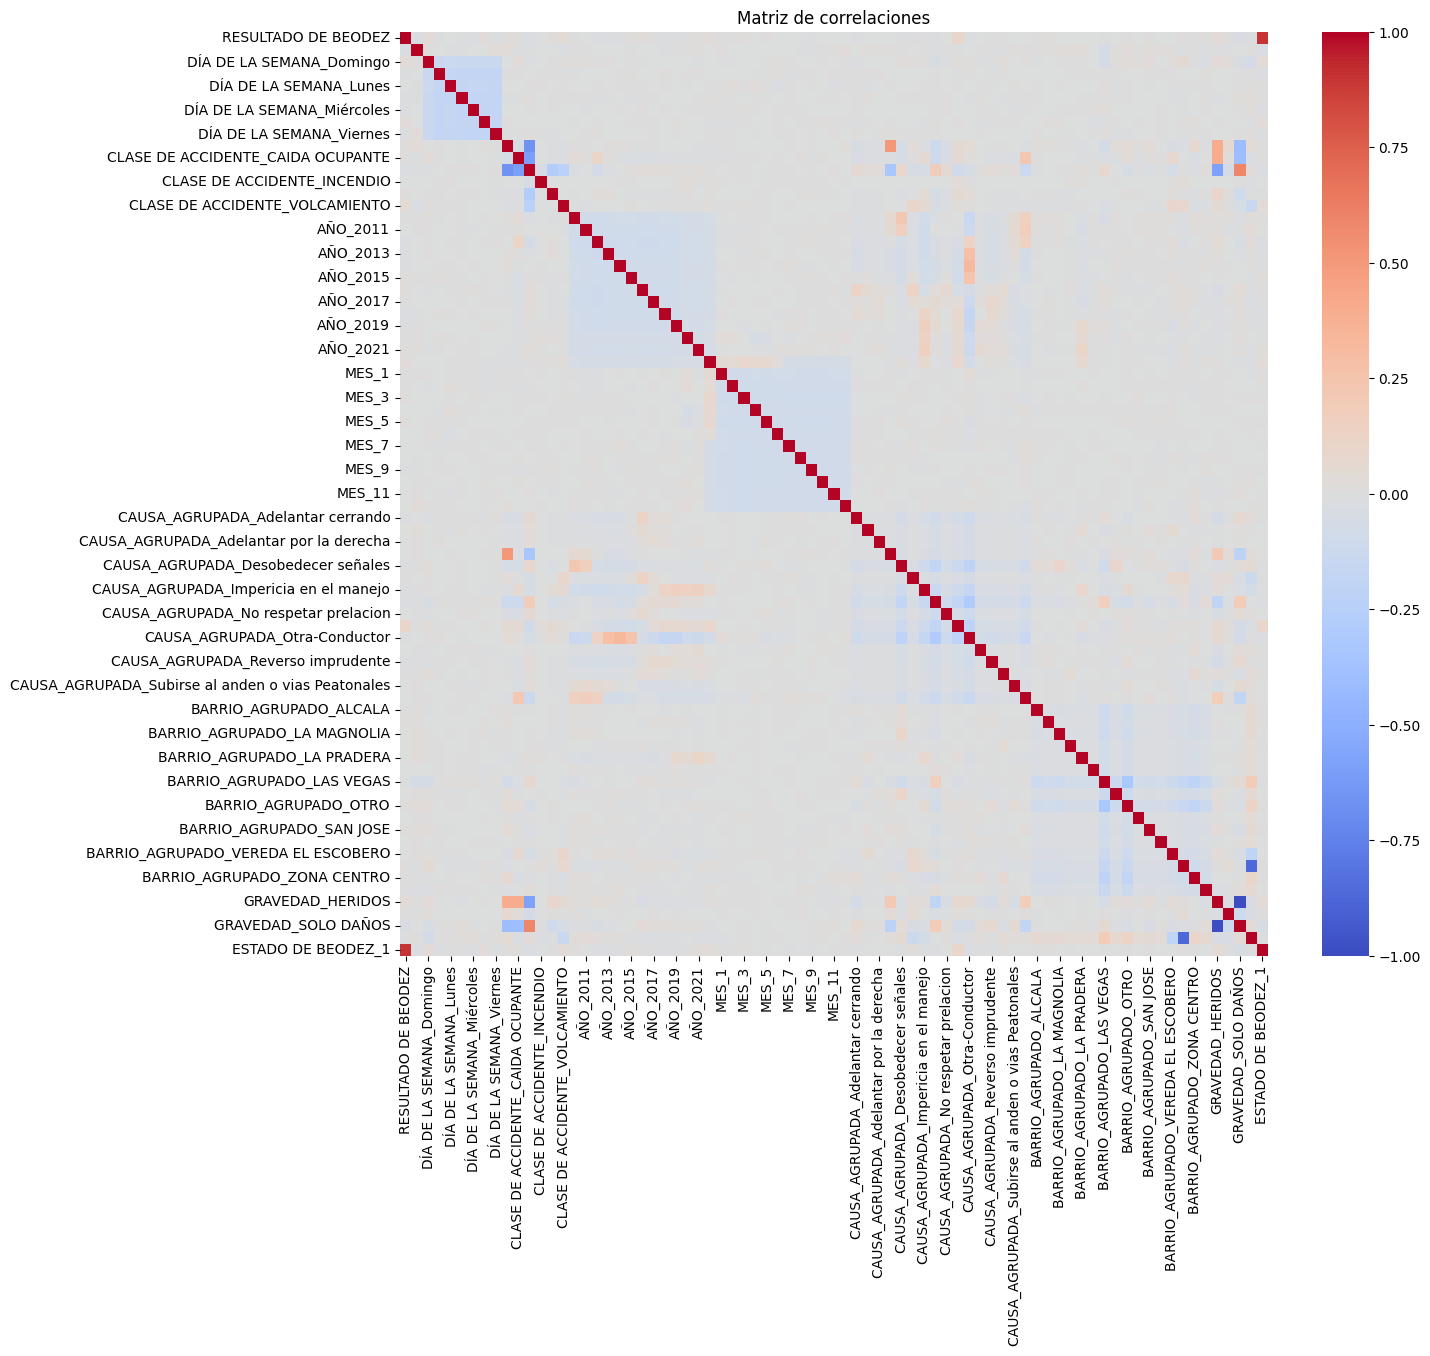

In [ ]:
plt.figure(figsize=(14, 12))
sns.heatmap(correlaciones, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlaciones')
plt.show()

In [ ]:
# Pares con correlación absoluta > 0.8 (excluyendo la diagonal)
pares_altos = []
cols = correlaciones.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = correlaciones.iloc[i, j]
        if abs(v) > 0.8:
            pares_altos.append((cols[i], cols[j], round(v, 3)))

pd.DataFrame(pares_altos, columns=['Variable 1', 'Variable 2', 'Correlación'])

,Variable 1,Variable 2,Correlación
0,RESULTADO DE BEODEZ,ESTADO DE BEODEZ_1,0.899
1,BARRIO_AGRUPADO_VEREDA PALMAS,AREA_URBANA,-0.871
2,GRAVEDAD_HERIDOS,GRAVEDAD_SOLO DAÑOS,-0.990


Aparecen dos pares:

1. **`ESTADO DE BEODEZ_1` vs `RESULTADO DE BEODEZ` (0.899):** redundancia real. `RESULTADO DE BEODEZ` (0=negativo, 1-3=niveles de embriaguez) ya contiene la información de `ESTADO DE BEODEZ_1` (0/1) como caso particular — es prácticamente la misma variable con más detalle. Eliminamos `ESTADO DE BEODEZ` en `data` y conservamos `RESULTADO DE BEODEZ`, que es más informativa.
2. **`AREA_URBANA` vs `BARRIO_AGRUPADO_VEREDA PALMAS` (-0.871):** esta es una coincidencia esperada por definición geográfica — una "vereda" es por definición zona rural, así que ese barrio específico está perfectamente asociado a `AREA=RURAL`. No es una redundancia de la variable `AREA` completa (los otros 15 barrios no reproducen esa relación), así que **no** eliminamos `AREA` por este hallazgo puntual.

In [ ]:
# Eliminamos la variable redundante confirmada
data.drop(columns=['ESTADO DE BEODEZ'], inplace=True)
data.columns.tolist()

['DÍA DE LA SEMANA',
 'RESULTADO DE BEODEZ',
 'GRAVEDAD',
 'CLASE DE ACCIDENTE',
 'AREA',
 'AÑO',
 'MES',
 'HORA_DIA',
 'CAUSA_AGRUPADA',
 'BARRIO_AGRUPADO']

# 7. Correlaciones para irrelevancia con la variable objetivo

Buscamos variables cuya correlación con `GRAVEDAD` sea muy baja (0.0-0.05): si una variable casi no se mueve junto con el objetivo, aporta poco para predecirlo.

Como `GRAVEDAD` tiene 3 categorías, al hacer *dummy* (con `drop_first`) quedan 2 columnas objetivo (la categoría base, la primera en orden alfabético, no genera columna). Revisamos la correlación de cada predictora frente a ambas.

In [ ]:
correlaciones = data_num.corr()

cols_objetivo = [c for c in correlaciones.columns if c.startswith('GRAVEDAD_')]
print("Columnas objetivo (dummy):", cols_objetivo)
cor_variable_obj = correlaciones[cols_objetivo].drop(index=cols_objetivo)
cor_variable_obj.sort_values(by=cols_objetivo[0], key=abs, ascending=False).head(15)

Columnas objetivo (dummy): ['GRAVEDAD_HERIDOS', 'GRAVEDAD_MUERTOS', 'GRAVEDAD_SOLO DAÑOS']


,GRAVEDAD_HERIDOS,GRAVEDAD_MUERTOS,GRAVEDAD_SOLO DAÑOS
CLASE DE ACCIDENTE_CHOQUE,-0.584263,-0.065396,0.590021
CLASE DE ACCIDENTE_ATROPELLO,0.401925,0.067392,-0.409055
CLASE DE ACCIDENTE_CAIDA OCUPANTE,0.401232,0.022303,-0.401990
CAUSA_AGRUPADA_Cruzar sin observar,0.212713,0.038181,-0.216842
CAUSA_AGRUPADA_No mantener distancia de seguridad,-0.188475,-0.027299,0.191210
CAUSA_AGRUPADA_Transitar entre vehiculos,0.183717,0.014806,-0.184713
CLASE DE ACCIDENTE_OTRO,0.095626,0.011083,-0.096622
CAUSA_AGRUPADA_Adelantar cerrando,-0.067980,-0.010313,0.069032
CAUSA_AGRUPADA_OTRA,0.065660,0.017284,-0.067712
CAUSA_AGRUPADA_Otra-Conductor,0.063525,0.014284,-0.065165


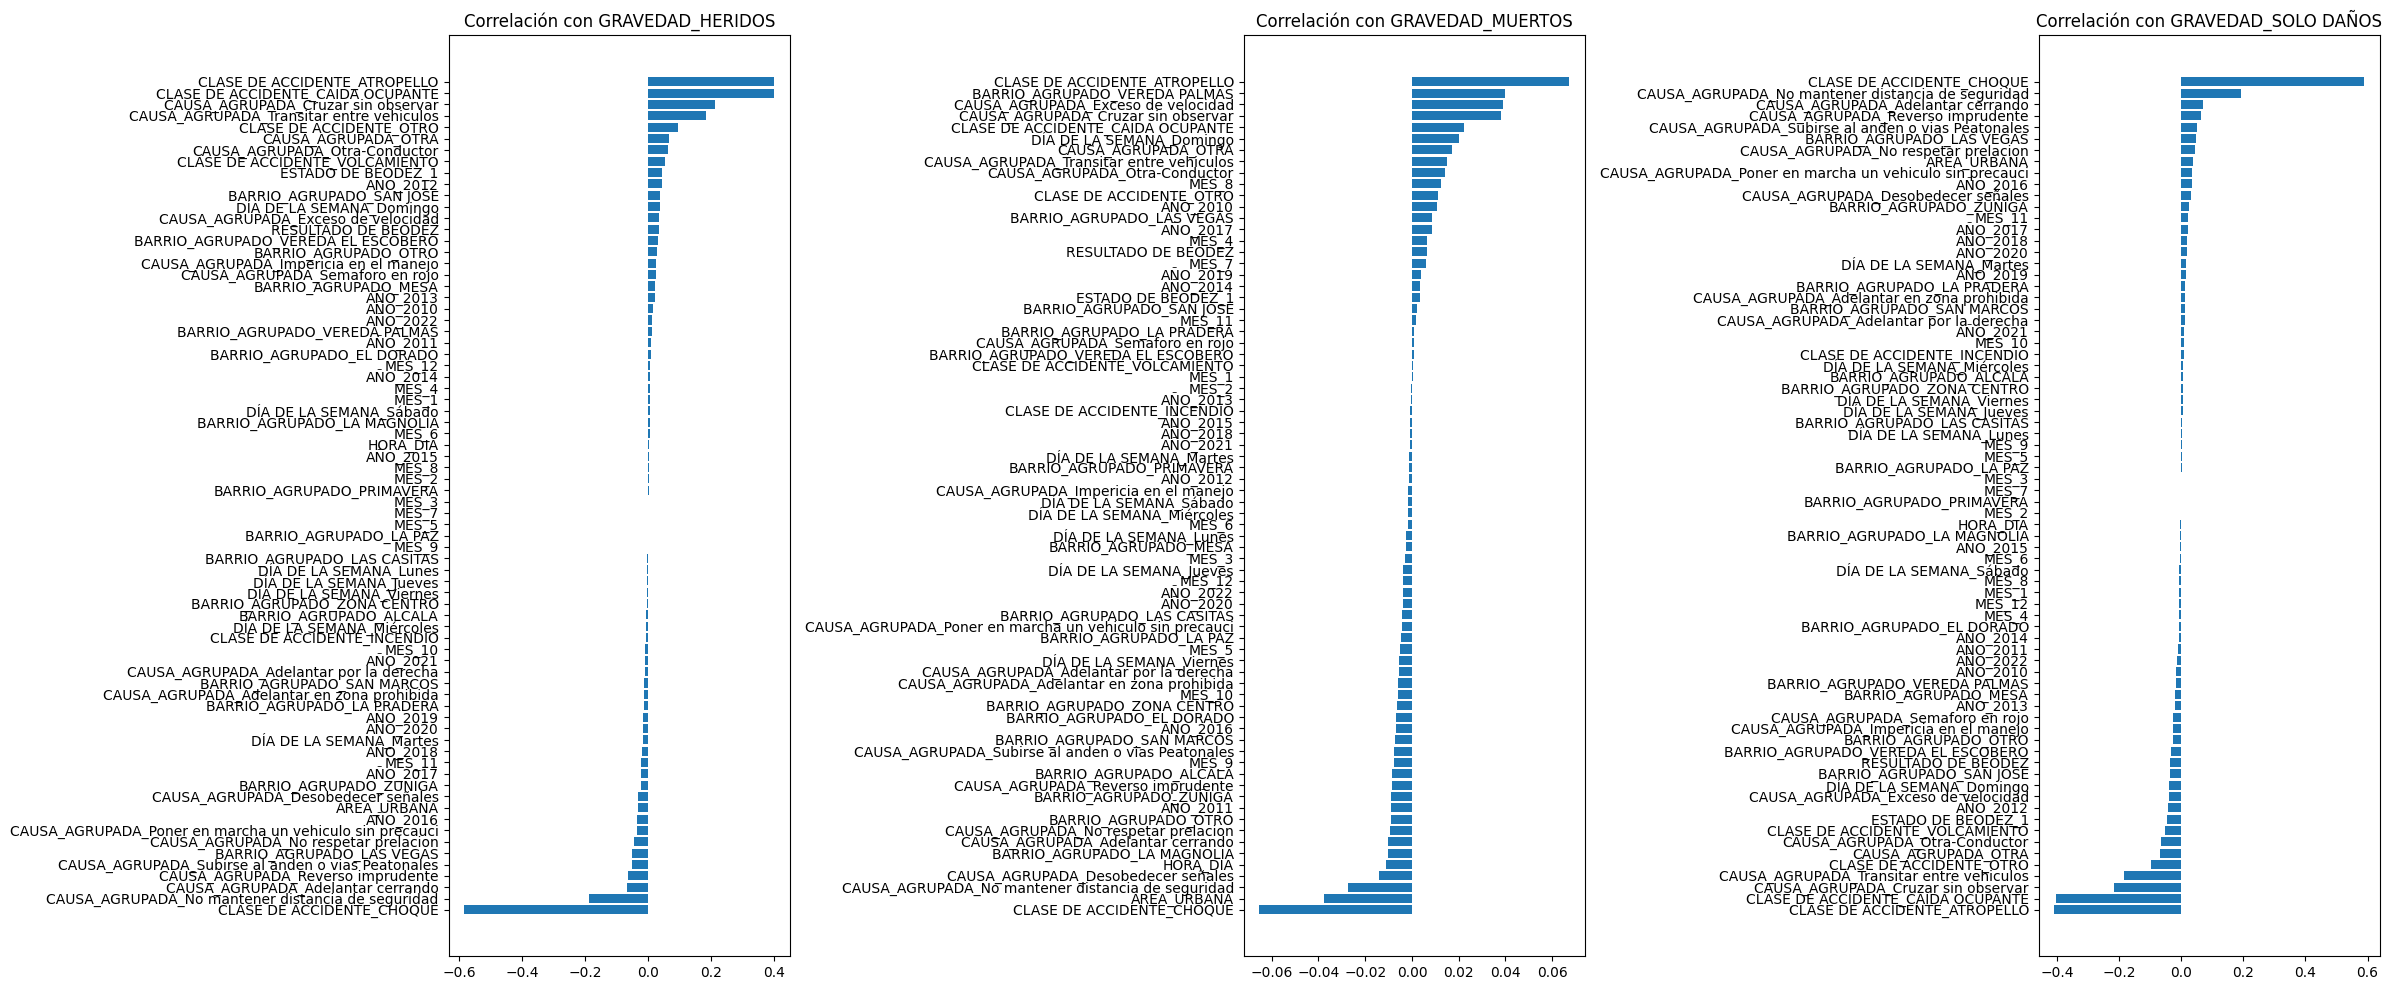

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
for ax, col in zip(axes, cols_objetivo):
    s = cor_variable_obj[col].sort_values()
    ax.barh(s.index, s.values)
    ax.set_title(f'Correlación con {col}')
plt.tight_layout()
plt.show()

**Nota:** la correlación con `GRAVEDAD_MUERTOS` es baja en general para *todas* las variables — es esperable, porque MUERTOS representa apenas el 0.3% de los registros (muy poca variabilidad estadística para correlacionar linealmente). Una correlación baja aquí no siempre implica irrelevancia real, sino falta de casos.

Para decidir qué eliminar agregamos la correlación máxima absoluta de cada variable original (agrupando sus *dummies*) frente al objetivo.

In [ ]:
variables_originales = ['DÍA DE LA SEMANA', 'RESULTADO DE BEODEZ', 'CLASE DE ACCIDENTE',
                          'AREA', 'AÑO', 'MES', 'HORA_DIA', 'CAUSA_AGRUPADA', 'BARRIO_AGRUPADO']

def variable_base(col):
    for v in variables_originales:
        if col == v or col.startswith(v + '_'):
            return v
    return col

resumen = {}
for col in cor_variable_obj.index:
    base = variable_base(col)
    valor = cor_variable_obj.loc[col].abs().max()
    resumen.setdefault(base, []).append(valor)

resumen_df = pd.DataFrame({k: [max(v)] for k, v in resumen.items()}, index=['correlación_máx_abs']).T
resumen_df.sort_values('correlación_máx_abs')

,correlación_máx_abs
HORA_DIA,0.010910
MES,0.021157
RESULTADO DE BEODEZ,0.035337
AREA,0.037520
DÍA DE LA SEMANA,0.039377
AÑO,0.043117
ESTADO DE BEODEZ_1,0.045026
BARRIO_AGRUPADO,0.049683
CAUSA_AGRUPADA,0.216842
CLASE DE ACCIDENTE,0.590021


`HORA_DIA` (0.011), `DÍA DE LA SEMANA` (0.017) y `MES` (0.021) son las variables con menor correlación con el objetivo. De estas, `AÑO` (0.043) es la que decidimos eliminar: además de tener una correlación baja, incluir el año exacto como predictor arriesga sobreajustar el modelo a los años observados (2010-2022) y perjudicar su capacidad de generalizar a años futuros — un argumento adicional al puramente estadístico.

`HORA_DIA`, `DÍA DE LA SEMANA` y `MES` se conservan: son variables cíclicas (la hora 23 está "cerca" de la hora 0, diciembre está "cerca" de enero) y la correlación lineal de Pearson subestima ese tipo de relaciones no monótonas, así que un valor bajo no es evidencia suficientemente fuerte para descartarlas.

In [ ]:
data.drop(columns=['AÑO'], inplace=True)
print("Variables predictoras finales:", [c for c in data.columns if c != 'GRAVEDAD'])
print("Total variables predictoras:", data.shape[1] - 1)

Variables predictoras finales: ['DÍA DE LA SEMANA', 'RESULTADO DE BEODEZ', 'CLASE DE ACCIDENTE', 'AREA', 'MES', 'HORA_DIA', 'CAUSA_AGRUPADA', 'BARRIO_AGRUPADO']
Total variables predictoras: 8


# 8. Balanceo de la variable objetivo (Clasificación)

`GRAVEDAD` está muy desbalanceada: cerca del 79.5 % de los siniestros son "SOLO DAÑOS", el 20.2 % "HERIDOS" y apenas el 0.3 % "MUERTOS". Un modelo entrenado así tendería a ignorar las clases minoritarias. Decisiones:

1. **Se elimina la clase MUERTOS:** con el 0.3 % de los registros no hay suficientes casos reales para aprender un patrón confiable, y sobremuestrearla implicaría inventar casi todos sus registros. El problema pasa a ser **binario: SOLO DAÑOS vs HERIDOS**.
2. **Submuestreo de SOLO DAÑOS al 75 %** (`RandomUnderSampler`): se descarta al azar la mitad de los registros de la clase mayoritaria.
3. **Sobremuestreo de HERIDOS** con **SMOTENC** (variante de SMOTE que soporta variables categóricas + numéricas mezcladas) hasta llevar a SOLO DAÑOS y HERIDOS hasta una proporción de 2:1.

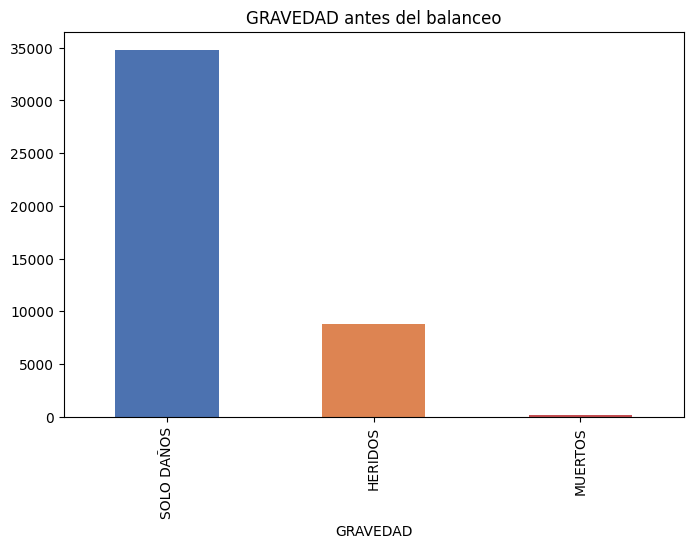

,proportion
GRAVEDAD,
SOLO DAÑOS,79.5
HERIDOS,20.2
MUERTOS,0.3


In [ ]:
conteo = data['GRAVEDAD'].value_counts()
porcentaje = data['GRAVEDAD'].value_counts(normalize=True).round(3) * 100
ax = conteo.plot(kind='bar', color=['#4C72B0', '#DD8452', '#C44E52'])
plt.title('GRAVEDAD antes del balanceo')
plt.show()
porcentaje

In [ ]:
# Eliminamos la clase MUERTOS: el problema pasa a ser binario
data = data[data['GRAVEDAD'] != 'MUERTOS'].copy()
data['GRAVEDAD'] = data['GRAVEDAD'].astype(str).astype('category')
print("Shape sin MUERTOS:", data.shape)
data['GRAVEDAD'].value_counts()

Shape sin MUERTOS: (43616, 9)


,count
GRAVEDAD,
SOLO DAÑOS,34794
HERIDOS,8822


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTENC

X = data.drop(columns=['GRAVEDAD'])
Y = data['GRAVEDAD'].astype(str)

# Copia de los datos reales (binarios, sin balancear) para la verificación de la sección 11
X_real = X.copy()
Y_real = Y.copy()

# 1) Submuestreo: SOLO DAÑOS se reduce a 3/4 de su valor original
n_danos = (Y == 'SOLO DAÑOS').sum()
rus = RandomUnderSampler(sampling_strategy={'SOLO DAÑOS': int(n_danos * 0.75)}, random_state=42)
X_sub, Y_sub = rus.fit_resample(X, Y)
print("Después del submuestreo:", Y_sub.value_counts().to_dict())

# 2) Sobremuestreo: HERIDOS sube con SMOTENC hasta igualar a SOLO DAÑOS
columnas_categoricas = ['DÍA DE LA SEMANA', 'CLASE DE ACCIDENTE', 'AREA', 'MES',
                         'CAUSA_AGRUPADA', 'BARRIO_AGRUPADO']
indices_categoricos = [X.columns.get_loc(c) for c in columnas_categoricas]
sm = SMOTENC(categorical_features=indices_categoricos, sampling_strategy=0.5, random_state=42)
X_bal, Y_bal = sm.fit_resample(X_sub, Y_sub)

print("Shape antes:", X.shape, "-> Shape después:", X_bal.shape)

Después del submuestreo: {'SOLO DAÑOS': 26095, 'HERIDOS': 8822}
Shape antes: (43616, 8) -> Shape después: (39142, 8)


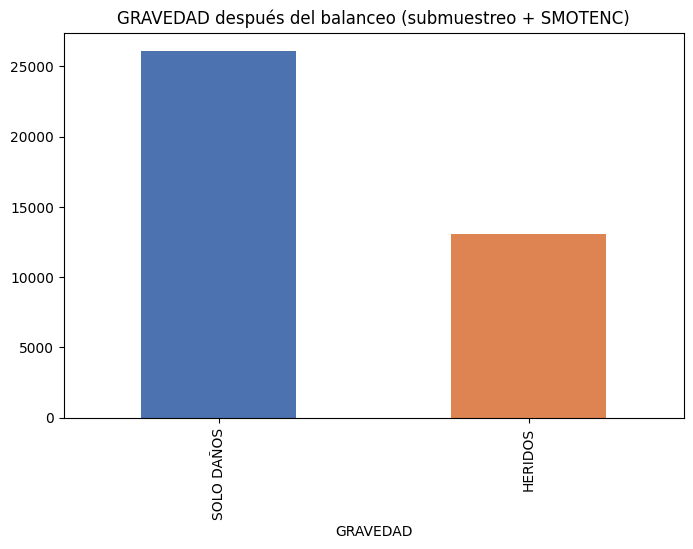

,count
GRAVEDAD,
SOLO DAÑOS,26095
HERIDOS,13047


In [ ]:
# Reconstruimos el dataframe balanceado.
# Se mezclan las filas: SMOTENC agrega los registros sintéticos al final y la validación
# cruzada de GridSearchCV (StratifiedKFold sin shuffle) los concentraría en los últimos folds.
data = pd.DataFrame(X_bal, columns=X.columns).reset_index(drop=True)
data['GRAVEDAD'] = pd.Series(Y_bal).reset_index(drop=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

data['GRAVEDAD'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('GRAVEDAD después del balanceo (submuestreo + SMOTENC)')
plt.show()
data['GRAVEDAD'].value_counts()

**Resultado:** se eliminó MUERTOS, SOLO DAÑOS se redujo al 75% de su tamaño original y HERIDOS se completó con registros sintéticos de SMOTENC hasta llegar a una proporción 2:1; por cada registro de HERIDOS hay dos de SOLO DAÑOS. Nos rehusamos a llegar al balance perfecto (50/50) por evitar introducir demasiados datos sintéticos en HERIDOS o eliminar demasiados registros en SOLO DAÑOS. En cualquier caso, se conservan `X_real` / `Y_real` (datos reales, binarios y sin balancear) para la verificación final de la sección 11.

# 9. Transformaciones

- Si el método de ML requiere variables **categóricas/discretas** (árboles, Bayes) → discretización (9.1).
- Si el método de ML requiere variables **numéricas y normalizadas** (redes neuronales, regresión, SVM, KNN, K-means) → normalización + dummies + label encoder (9.2 a 9.4).

Guardamos dos versiones del dataset balanceado: `data_cat` (para métodos categóricos) y `data` (para métodos numéricos). En la sección 11 los seis modelos (incluidos los de árboles) se entrenan con la versión numérica `data`, para compararlos sobre las mismas variables.

In [ ]:
data_cat = data.copy()

**`9.1 Discretización`**: transformación de número a categoría.

Las dos variables numéricas del dataset son `HORA_DIA` (0-23) y `RESULTADO DE BEODEZ` (0-3, ordinal).

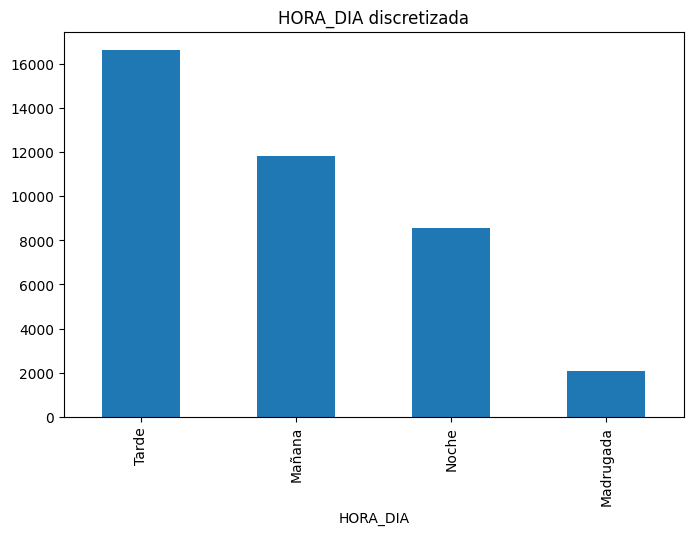

In [ ]:
# HORA_DIA -> franja horaria con nombres de categoría
data_cat['HORA_DIA'] = pd.cut(
    data_cat['HORA_DIA'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Madrugada', 'Mañana', 'Tarde', 'Noche']
)
data_cat['HORA_DIA'].value_counts().plot(kind='bar')
plt.title('HORA_DIA discretizada')
plt.show()

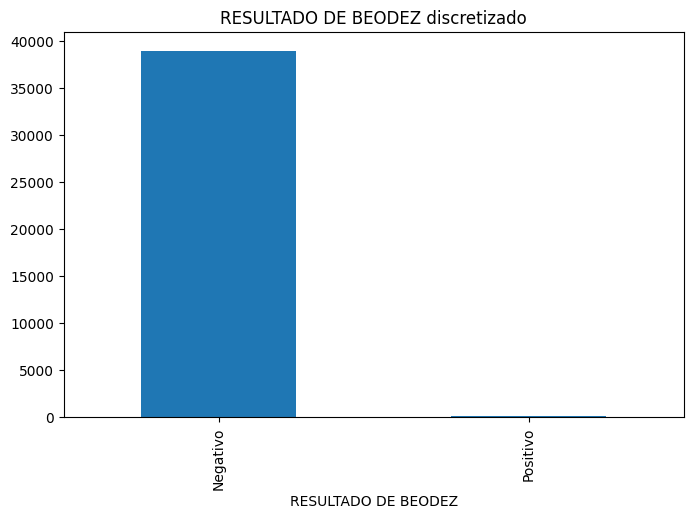

In [ ]:
# RESULTADO DE BEODEZ -> categoría binaria
data_cat['RESULTADO DE BEODEZ'] = pd.cut(
    data_cat['RESULTADO DE BEODEZ'],
    bins=[-1, 0, 3],
    labels=['Negativo', 'Positivo']
)
data_cat['RESULTADO DE BEODEZ'].value_counts().plot(kind='bar')
plt.title('RESULTADO DE BEODEZ discretizado')
plt.show()

In [ ]:
data_cat.head()

,DÍA DE LA SEMANA,RESULTADO DE BEODEZ,CLASE DE ACCIDENTE,AREA,MES,HORA_DIA,CAUSA_AGRUPADA,BARRIO_AGRUPADO,GRAVEDAD
0,Miércoles,Negativo,CHOQUE,URBANA,10,Tarde,Transitar entre vehiculos,LAS CASITAS,SOLO DAÑOS
1,Miércoles,Negativo,CHOQUE,RURAL,11,Tarde,OTRA,VEREDA PALMAS,SOLO DAÑOS
2,Lunes,Negativo,CHOQUE,URBANA,5,Tarde,Desobedecer señales,OTRO,HERIDOS
3,Viernes,Negativo,ATROPELLO,RURAL,11,Mañana,OTRA,VEREDA PALMAS,HERIDOS
4,Lunes,Negativo,CHOQUE,URBANA,4,Tarde,Desobedecer señales,OTRO,SOLO DAÑOS


**`9.2 Normalización de variables numéricas`**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
data[['HORA_DIA', 'RESULTADO DE BEODEZ']] = min_max_scaler.fit_transform(data[['HORA_DIA', 'RESULTADO DE BEODEZ']])
data[['HORA_DIA', 'RESULTADO DE BEODEZ']].describe()

,HORA_DIA,RESULTADO DE BEODEZ
count,39142.000000,39142.000000
mean,0.576414,0.002274
std,0.220580,0.040897
min,0.000000,0.000000
25%,0.391304,0.000000
50%,0.608696,0.000000
75%,0.739130,0.000000
max,1.000000,1.000000


**`9.3 Dummies:`** transformación de categorías a números (solo para el dataset numérico/normalizado)

In [ ]:
columnas_categoricas = ['DÍA DE LA SEMANA', 'CLASE DE ACCIDENTE', 'MES',
                         'CAUSA_AGRUPADA', 'BARRIO_AGRUPADO']
data = pd.get_dummies(data, columns=columnas_categoricas, drop_first=False, dtype=int)

# El área termina siendo binaria por imputar las "no reportadas"
data = pd.get_dummies(data, columns=['AREA'], drop_first=True, dtype=int)
data.head()

,RESULTADO DE BEODEZ,HORA_DIA,GRAVEDAD,DÍA DE LA SEMANA_Domingo,DÍA DE LA SEMANA_Jueves,DÍA DE LA SEMANA_Lunes,DÍA DE LA SEMANA_Martes,DÍA DE LA SEMANA_Miércoles,DÍA DE LA SEMANA_Sábado,DÍA DE LA SEMANA_Viernes,CLASE DE ACCIDENTE_ATROPELLO,CLASE DE ACCIDENTE_CAIDA OCUPANTE,CLASE DE ACCIDENTE_CHOQUE,CLASE DE ACCIDENTE_INCENDIO,CLASE DE ACCIDENTE_OTRO,CLASE DE ACCIDENTE_VOLCAMIENTO,MES_1,MES_2,MES_3,MES_4,MES_5,MES_6,MES_7,MES_8,MES_9,MES_10,MES_11,MES_12,CAUSA_AGRUPADA_Adelantar cerrando,CAUSA_AGRUPADA_Adelantar en zona prohibida,CAUSA_AGRUPADA_Adelantar por la derecha,CAUSA_AGRUPADA_Cruzar sin observar,CAUSA_AGRUPADA_Desobedecer señales,CAUSA_AGRUPADA_Exceso de velocidad,CAUSA_AGRUPADA_Impericia en el manejo,CAUSA_AGRUPADA_No mantener distancia de seguridad,CAUSA_AGRUPADA_No respetar prelacion,CAUSA_AGRUPADA_OTRA,CAUSA_AGRUPADA_Otra-Conductor,CAUSA_AGRUPADA_Poner en marcha un vehiculo sin precauci,CAUSA_AGRUPADA_Reverso imprudente,CAUSA_AGRUPADA_Semaforo en rojo,CAUSA_AGRUPADA_Subirse al anden o vias Peatonales,CAUSA_AGRUPADA_Transitar entre vehiculos,BARRIO_AGRUPADO_ALCALA,BARRIO_AGRUPADO_EL DORADO,BARRIO_AGRUPADO_LA MAGNOLIA,BARRIO_AGRUPADO_LA PAZ,BARRIO_AGRUPADO_LA PRADERA,BARRIO_AGRUPADO_LAS CASITAS,BARRIO_AGRUPADO_LAS VEGAS,BARRIO_AGRUPADO_MESA,BARRIO_AGRUPADO_OTRO,BARRIO_AGRUPADO_PRIMAVERA,BARRIO_AGRUPADO_SAN JOSE,BARRIO_AGRUPADO_SAN MARCOS,BARRIO_AGRUPADO_VEREDA EL ESCOBERO,BARRIO_AGRUPADO_VEREDA PALMAS,BARRIO_AGRUPADO_ZONA CENTRO,BARRIO_AGRUPADO_ZUÑIGA,AREA_URBANA
0,0.0,0.565217,SOLO DAÑOS,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
1,0.0,0.565217,SOLO DAÑOS,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0.0,0.652174,HERIDOS,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
3,0.0,0.304348,HERIDOS,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0.0,0.739130,SOLO DAÑOS,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


**`9.4 Label Encoder:`** solo para la variable objetivo

In [ ]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
data['GRAVEDAD'] = labelencoder.fit_transform(data['GRAVEDAD'])
print("Clases codificadas:", dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_))))
data.head()

Clases codificadas: {'HERIDOS': np.int64(0), 'SOLO DAÑOS': np.int64(1)}


,RESULTADO DE BEODEZ,HORA_DIA,GRAVEDAD,DÍA DE LA SEMANA_Domingo,DÍA DE LA SEMANA_Jueves,DÍA DE LA SEMANA_Lunes,DÍA DE LA SEMANA_Martes,DÍA DE LA SEMANA_Miércoles,DÍA DE LA SEMANA_Sábado,DÍA DE LA SEMANA_Viernes,CLASE DE ACCIDENTE_ATROPELLO,CLASE DE ACCIDENTE_CAIDA OCUPANTE,CLASE DE ACCIDENTE_CHOQUE,CLASE DE ACCIDENTE_INCENDIO,CLASE DE ACCIDENTE_OTRO,CLASE DE ACCIDENTE_VOLCAMIENTO,MES_1,MES_2,MES_3,MES_4,MES_5,MES_6,MES_7,MES_8,MES_9,MES_10,MES_11,MES_12,CAUSA_AGRUPADA_Adelantar cerrando,CAUSA_AGRUPADA_Adelantar en zona prohibida,CAUSA_AGRUPADA_Adelantar por la derecha,CAUSA_AGRUPADA_Cruzar sin observar,CAUSA_AGRUPADA_Desobedecer señales,CAUSA_AGRUPADA_Exceso de velocidad,CAUSA_AGRUPADA_Impericia en el manejo,CAUSA_AGRUPADA_No mantener distancia de seguridad,CAUSA_AGRUPADA_No respetar prelacion,CAUSA_AGRUPADA_OTRA,CAUSA_AGRUPADA_Otra-Conductor,CAUSA_AGRUPADA_Poner en marcha un vehiculo sin precauci,CAUSA_AGRUPADA_Reverso imprudente,CAUSA_AGRUPADA_Semaforo en rojo,CAUSA_AGRUPADA_Subirse al anden o vias Peatonales,CAUSA_AGRUPADA_Transitar entre vehiculos,BARRIO_AGRUPADO_ALCALA,BARRIO_AGRUPADO_EL DORADO,BARRIO_AGRUPADO_LA MAGNOLIA,BARRIO_AGRUPADO_LA PAZ,BARRIO_AGRUPADO_LA PRADERA,BARRIO_AGRUPADO_LAS CASITAS,BARRIO_AGRUPADO_LAS VEGAS,BARRIO_AGRUPADO_MESA,BARRIO_AGRUPADO_OTRO,BARRIO_AGRUPADO_PRIMAVERA,BARRIO_AGRUPADO_SAN JOSE,BARRIO_AGRUPADO_SAN MARCOS,BARRIO_AGRUPADO_VEREDA EL ESCOBERO,BARRIO_AGRUPADO_VEREDA PALMAS,BARRIO_AGRUPADO_ZONA CENTRO,BARRIO_AGRUPADO_ZUÑIGA,AREA_URBANA
0,0.0,0.565217,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
1,0.0,0.565217,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0.0,0.652174,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
3,0.0,0.304348,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0.0,0.739130,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


# 10. Guardar los datos preparados

In [ ]:
data_cat.to_excel("datos_categoricos_discretizados.xlsx", index=False)
print("Guardado: datos_categoricos_discretizados.xlsx", data_cat.shape)

Guardado: datos_categoricos_discretizados.xlsx (39142, 9)


In [ ]:
data.to_excel("datos_numericos_normalizados.xlsx", index=False)
print("Guardado: datos_numericos_normalizados.xlsx", data.shape)

Guardado: datos_numericos_normalizados.xlsx (39142, 61)


# 11. Modelos de clasificación con hiperparametrización

Se entrenan seis modelos: árbol de decisión, Random Forest, XGBoost, KNN, SVM y red neuronal. En lugar de dividir en entrenamiento/prueba (70/30), cada modelo se ajusta con **`GridSearchCV`** usando **validación cruzada de 10 folds** y la medida **f1 macro**.

Se usa el dataset numérico `data` de la sección 9 (balanceado, normalizado, con dummies y label encoder). Para cada modelo se revisa el overfitting/underfitting comparando el f1 promedio en entrenamiento (Train CV) y en validación (Test CV).

In [ ]:
# Configuración hiperparametrización
from sklearn.model_selection import GridSearchCV
scoring = 'f1_macro'
cv = 10

# Configuración de datos
X = data.drop('GRAVEDAD', axis=1)  # Variables predictoras
Y = data['GRAVEDAD']               # Variable objetivo

# Medida de evaluación del mejor modelo
medidas = pd.DataFrame(index=['f1 de la CV'])
print("X:", X.shape, "| registros por clase:", dict(zip(labelencoder.classes_, np.bincount(Y))))

X: (39142, 60) | registros por clase: {'HERIDOS': np.int64(13047), 'SOLO DAÑOS': np.int64(26095)}


## 11.1. Árbol de decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
modelTree = DecisionTreeClassifier(random_state=42)

# Definir los hiperparámetros
criterion = ['entropy', 'gini']      # Índice de información
min_samples_leaf = [2, 10, 50, 100]  # Cantidad de registros por hoja
max_depth = [None, 10, 20, 50]       # Niveles de profundidad

# Hiperparametrización
param_grid = dict(criterion=criterion, min_samples_leaf=min_samples_leaf, max_depth=max_depth)
grid = GridSearchCV(estimator=modelTree, param_grid=param_grid, scoring=scoring, cv=cv,
                    return_train_score=True, refit=True, n_jobs=-1)
grid.fit(X, Y)

# Mejor modelo
modelTree = grid.best_estimator_

# Mejores parámetros
print(grid.best_params_)

# Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

# Comparación de medidas
medidas['Tree'] = grid.best_score_
medidas

{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10}
Train CV: 0.8066122857587124
Test CV: 0.7582127802089121


,Tree
f1 de la CV,0.758213


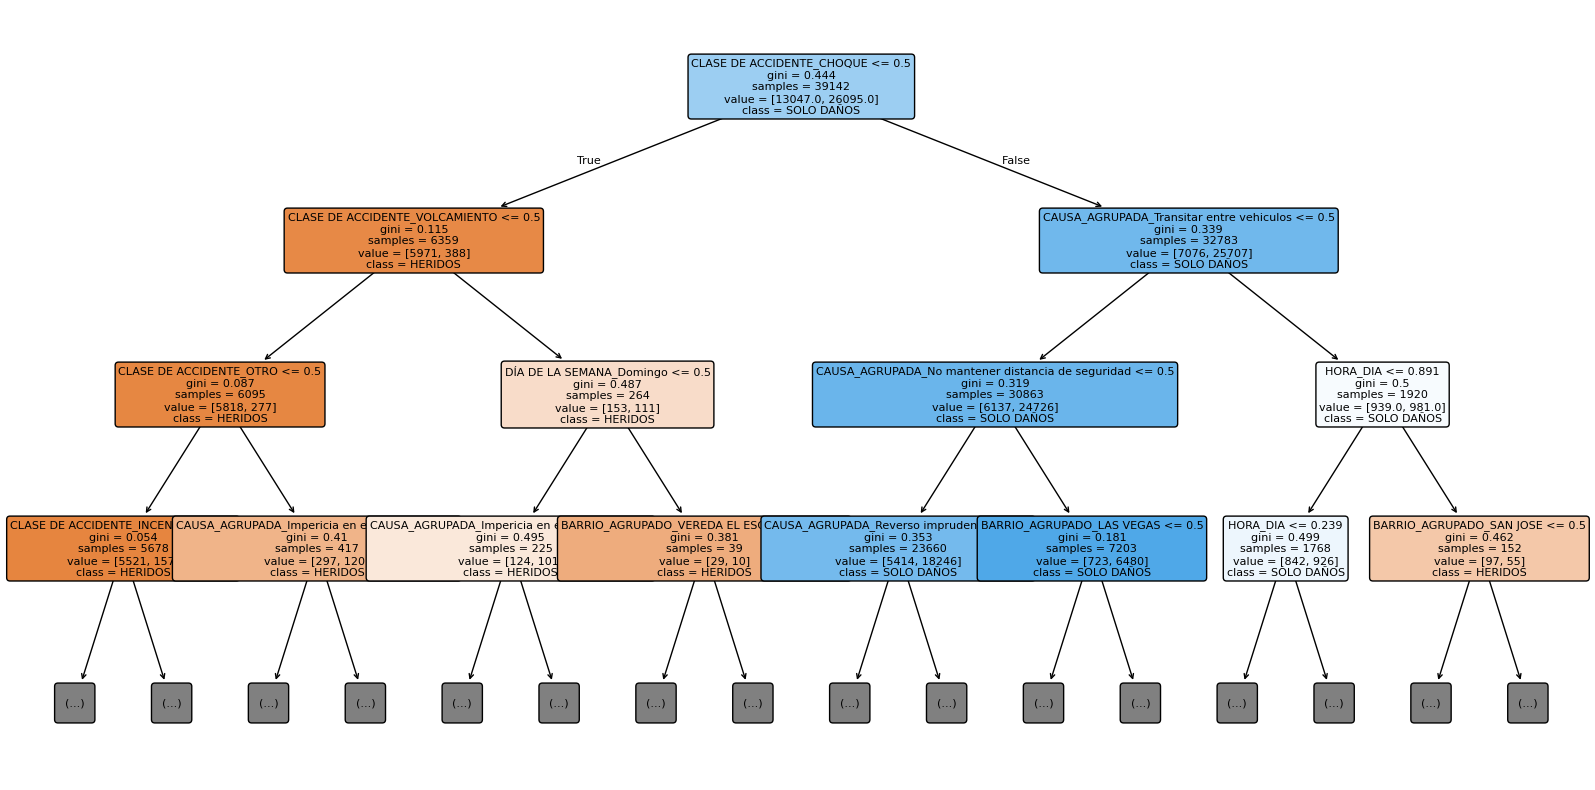

In [ ]:
# Mejor árbol (se dibujan solo los 3 primeros niveles para que sea legible)
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(modelTree, feature_names=X.columns.values, class_names=labelencoder.classes_,
          max_depth=3, rounded=True, filled=True, fontsize=8)
plt.show()

## 11.2. Random Forest

Respecto a la configuración inicial propuesta (`n_estimators` de 1 a 4, `max_depth` de 1 a 7 y `class_weight='balanced_subsample'`): `n_estimators` sube a 50-200 (1 a 4 árboles no forman un bosque útil), `max_depth` usa 10/20/None (profundidades de 1 a 7 tienden a subajustar) y se quita `class_weight` porque los datos ya están balanceados.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
modelRF = RandomForestClassifier(random_state=42, n_jobs=-1)

# Definir los hiperparámetros
n_estimators = [50, 100, 200]       # Cantidad de árboles
criterion = ['gini', 'entropy']     # Índice de información
max_depth = [None, 10, 20]          # Niveles de profundidad
min_samples_leaf = [2, 10]          # Cantidad de registros por hoja
max_features = ['sqrt']             # Variables candidatas en cada división

# Hiperparametrización
param_grid = dict(n_estimators=n_estimators, criterion=criterion, max_depth=max_depth,
                  min_samples_leaf=min_samples_leaf, max_features=max_features)
grid = GridSearchCV(estimator=modelRF, param_grid=param_grid, scoring=scoring, cv=cv,
                    return_train_score=True, refit=True, n_jobs=-1)
grid.fit(X, Y)

# Mejor modelo
modelRF = grid.best_estimator_
print(grid.best_params_)

# Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

# Comparación de medidas
medidas['RF'] = grid.best_score_
medidas

## 11.3. XGBoost

Ensamble de árboles construidos de forma secuencial: cada árbol corrige los errores de los anteriores. `learning_rate` controla cuánto aporta cada árbol y `subsample` la fracción de registros que ve cada uno.

In [ ]:
from xgboost import XGBClassifier
modelXGB = XGBClassifier(eval_metric='logloss', tree_method='hist', random_state=42, n_jobs=-1)

# Definir los hiperparámetros
n_estimators = [100, 200]           # Cantidad de árboles
max_depth = [3, 6, 9]               # Profundidad de cada árbol
learning_rate = [0.05, 0.1, 0.3]    # Tasa de aprendizaje
subsample = [0.8, 1.0]              # Fracción de registros por árbol

# Hiperparametrización
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth,
                  learning_rate=learning_rate, subsample=subsample)
grid = GridSearchCV(estimator=modelXGB, param_grid=param_grid, scoring=scoring, cv=cv,
                    return_train_score=True, refit=True, n_jobs=-1)
grid.fit(X, Y)

# Mejor modelo
modelXGB = grid.best_estimator_
print(grid.best_params_)

# Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

# Comparación de medidas
medidas['XGBoost'] = grid.best_score_
medidas

## 11.4. KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
modelKNN = KNeighborsClassifier()

# Definir los hiperparámetros
n_neighbors = [5, 15, 27]           # Cantidad de vecinos
weights = ['uniform', 'distance']   # Peso del voto de cada vecino

# Hiperparametrización
param_grid = dict(n_neighbors=n_neighbors, weights=weights)
grid = GridSearchCV(estimator=modelKNN, param_grid=param_grid, scoring=scoring, cv=cv,
                    return_train_score=True, refit=True, n_jobs=-1)
grid.fit(X, Y)

# Mejor modelo
modelKNN = grid.best_estimator_
print(grid.best_params_)

# Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

# Comparación de medidas
medidas['KNN'] = grid.best_score_
medidas

## 11.5. SVM

Es el modelo más costoso (SVC escala casi cuadráticamente con el número de registros), por eso se prueba un grid reducido. Puede tardar entre 20 y 40 minutos en Colab.

In [ ]:
from sklearn.svm import SVC
modelSVM = SVC(cache_size=512)

# Definir los hiperparámetros
kernel = ['rbf']    # Función kernel
C = [1, 10]         # Penalización por error

# Hiperparametrización
param_grid = dict(kernel=kernel, C=C)
grid = GridSearchCV(estimator=modelSVM, param_grid=param_grid, scoring=scoring, cv=cv,
                    return_train_score=True, refit=True, n_jobs=-1)
grid.fit(X, Y)

# Mejor modelo
modelSVM = grid.best_estimator_
print(grid.best_params_)

# Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

# Comparación de medidas
medidas['SVM'] = grid.best_score_
medidas

## 11.6. Red neuronal

In [ ]:
from sklearn.neural_network import MLPClassifier
modelNN = MLPClassifier(early_stopping=True, max_iter=300, random_state=42)

# Definir los hiperparámetros
hidden_layer_sizes = [(15,), (64, 32)]   # Neuronas por capa oculta
activation = ['relu', 'logistic']        # Función de activación

# Hiperparametrización
param_grid = dict(hidden_layer_sizes=hidden_layer_sizes, activation=activation)
grid = GridSearchCV(estimator=modelNN, param_grid=param_grid, scoring=scoring, cv=cv,
                    return_train_score=True, refit=True, n_jobs=-1)
grid.fit(X, Y)

# Mejor modelo
modelNN = grid.best_estimator_
print(grid.best_params_)

# Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

# Comparación de medidas
medidas['NN'] = grid.best_score_
medidas

## 11.7. Comparación de modelos

In [ ]:
print(medidas.T.sort_values('f1 de la CV', ascending=False))
medidas.T.sort_values('f1 de la CV').plot(kind='barh', legend=False)
plt.xlabel('f1 macro (validación cruzada, 10 folds)')
plt.title('Comparación de modelos')
plt.show()

modelos = {'Tree': modelTree, 'RF': modelRF, 'XGBoost': modelXGB,
           'KNN': modelKNN, 'SVM': modelSVM, 'NN': modelNN}
mejor_nombre = medidas.loc['f1 de la CV'].idxmax()
mejor_modelo = modelos[mejor_nombre]
print("Mejor modelo:", mejor_nombre, "| f1 CV:", round(medidas.loc['f1 de la CV', mejor_nombre], 4))

## 11.8. Verificación del mejor modelo con datos reales

En las secciones anteriores el balanceo (submuestreo + SMOTENC) se hizo **antes** de la validación cruzada. Esto hace que el f1 obtenido pueda ser **optimista** por dos razones:
1. **Fuga de información:** los registros sintéticos de HERIDOS se crean a partir de vecinos que luego caen en otros folds.
2. **Folds de validación artificiales:** se valida sobre datos 50/50 que incluyen registros sintéticos, mientras que en la realidad la proporción es cercana a 80/20 (y el f1 macro baja de forma natural cuando la clase minoritaria es escasa).

Para obtener una estimación realista, se reevalúa el mejor modelo con los datos reales (`X_real`, `Y_real`) y un `Pipeline` de imblearn que balancea **solo dentro del fold de entrenamiento**: el fold de validación siempre contiene accidentes reales con su proporción original. La diferencia entre ambos f1 combina los dos efectos anteriores.

*Nota:* si el mejor modelo es SVM, esta celda vuelve a entrenarlo 10 veces y puede tardar tanto como su búsqueda de hiperparámetros.

In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline

y_real = labelencoder.transform(Y_real)
clase_danos = labelencoder.transform(['SOLO DAÑOS'])[0]

def mitad_danos(y):
    # SOLO DAÑOS se reduce a la mitad, calculado sobre el fold de entrenamiento
    return {clase_danos: int((y == clase_danos).sum() // 2)}

categoricas = ['DÍA DE LA SEMANA', 'CLASE DE ACCIDENTE', 'AREA', 'MES',
               'CAUSA_AGRUPADA', 'BARRIO_AGRUPADO']
numericas = ['HORA_DIA', 'RESULTADO DE BEODEZ']
preparacion = ColumnTransformer([
    ('numericas', MinMaxScaler(), numericas),
    ('categoricas', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categoricas)
])

pipeline_real = Pipeline([
    ('submuestreo', RandomUnderSampler(sampling_strategy=mitad_danos, random_state=42)),
    ('smotenc', SMOTENC(categorical_features=[X_real.columns.get_loc(c) for c in categoricas],
                        random_state=42)),
    ('preparacion', preparacion),
    ('modelo', clone(mejor_modelo)),
])

cv_real = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
f1_real = cross_val_score(pipeline_real, X_real, y_real, cv=cv_real, scoring='f1_macro', n_jobs=-1)

f1_global = medidas.loc['f1 de la CV', mejor_nombre]
print(f"Mejor modelo: {mejor_nombre}")
print(f"f1 CV con balanceo global:                 {f1_global:.4f}")
print(f"f1 CV con datos reales (balanceo por fold): {f1_real.mean():.4f} ± {f1_real.std():.4f}")
print(f"Diferencia:                                {f1_global - f1_real.mean():.4f}")

## 11.9. Conclusiones

| Modelo | f1 Train CV | f1 Test CV | Brecha |
|---|---|---|---|
| KNN | 0,9607 | **0,8013** | 0,159 |
| Random Forest | 0,8551 | 0,7854 | 0,070 |
| XGBoost | 0,8982 | 0,7853 | 0,113 |
| SVM | 0,8070 | 0,7630 | 0,044 |
| Árbol de decisión | 0,8091 | 0,7599 | 0,049 |
| Red neuronal (MLP) | 0,7574 | 0,7565 | 0,001 |

- **Modelo elegido: Random Forest.** Ofrece el mejor equilibrio entre un F1 alto en validación y una menor brecha entre entrenamiento y validación respecto a KNN y XGBoost. Su F1 Test CV es de 0,7854 y su brecha es de 0,070.

- **KNN:** obtiene el mayor F1 Test CV, con 0,8013, pero también presenta la mayor brecha, de 0,159. Esta diferencia indica mayor sobreajuste: su desempeño en entrenamiento es considerablemente superior al de validación.

- **Random Forest frente a XGBoost:** ambos tienen resultados de validación prácticamente iguales: 0,7854 y 0,7853. Sin embargo, Random Forest presenta una brecha menor, de 0,070 frente a 0,113, lo que favorece su elección.

- **SVM y árbol de decisión:** presentan brechas menores, de 0,044 y 0,049, pero sus valores de F1 Test CV también son inferiores a los de Random Forest.

- **Red neuronal:** tiene la menor brecha, de 0,001, pero también el menor F1 Test CV, con 0,7565. Una brecha pequeña por sí sola no significa que un modelo sea el mejor ni confirma que exista underfitting.

- **Conclusión general:** se selecciona Random Forest para el despliegue porque mantiene un desempeño de validación cercano al de KNN y presenta menos señales de sobreajuste que KNN y XGBoost. Aunque no tiene la menor brecha de toda la tabla, ofrece un equilibrio favorable entre desempeño y generalización.

# 12. Modelo final

El modelo definido en `modelo_final` se entrena con las variables preparadas en este notebook. El archivo `.pkl` guarda el modelo, el codificador de la respuesta, las columnas predictoras, el escalador y las opciones de los desplegables.


In [ ]:
modelo_final = modelRF


In [ ]:
# Si selecciona Tree o RandomForest se desnormaliza con la siguiente instrucción
X[predictoras_numericas]= min_max_scaler.inverse_transform(X[predictoras_numericas])

In [ ]:
#Modelo final
modelo_final.fit(X, Y)


In [ ]:
import pickle

categoricas_despliegue = [
    'DÍA DE LA SEMANA',
    'CLASE DE ACCIDENTE',
    'AREA',
    'MES',
    'CAUSA_AGRUPADA',
    'BARRIO_AGRUPADO'
]

opciones = {}

for columna in categoricas_despliegue:
    serie = data_cat[columna]

    if isinstance(serie.dtype, pd.CategoricalDtype):
        valores = serie.cat.categories.tolist()
    else:
        valores = sorted(serie.dropna().unique().tolist())

    opciones[columna] = [str(valor) for valor in valores]

variables = X.columns.to_numpy()

with open('modelo-siniestros.pkl', 'wb') as archivo:
    pickle.dump(
        [
            modelo_final,
            labelencoder,
            variables,
            min_max_scaler,
            opciones
        ],
        archivo
    )

print("Guardado: modelo-siniestros.pkl")


# 13. Despliegue con Streamlit

Coloca `modelo-siniestros.pkl`, `app_siniestros_viales.py` y `requirements.txt` en la misma carpeta.

La interfaz permite seleccionar los ocho factores del siniestro, con la hora en un desplegable de 00:00 a 23:00. Las opciones están incluidas en el `.pkl`. Antes de predecir, se normalizan las variables numéricas y se reconstruyen las columnas en el orden del entrenamiento.

Se conserva la codificación de este notebook: todas las categorías para día, clase, mes, causa y barrio; para AREA, la categoría de referencia se representa con ceros. El resultado corresponde a HERIDOS o SOLO DAÑOS.


In [ ]:
!pip install "streamlit>=1.43" -q


In [ ]:
%%writefile app_siniestros_viales.py
from pathlib import Path
import html
import pickle

import pandas as pd
import streamlit as st


st.set_page_config(
    page_title="Envigado Vial",
    page_icon="🚦",
    layout="wide"
)

st.markdown("""
<style>
.stApp {
    background: #f3f6fa;
    color: #10263d;
}

.block-container {
    max-width: 1200px;
    padding-top: 2rem;
    padding-bottom: 2rem;
}

h1, h2, h3, p, label {
    font-family: "Segoe UI", sans-serif;
}

.marca {
    display: flex;
    align-items: center;
    justify-content: space-between;
    margin: 0 5px 24px;
}

.logo {
    display: flex;
    align-items: center;
    gap: 12px;
    font-size: 27px;
    font-weight: 750;
    color: #10263d;
}

.semaforo {
    background: #10263d;
    border-radius: 8px;
    width: 27px;
    padding: 5px 0;
    display: flex;
    flex-direction: column;
    align-items: center;
    gap: 3px;
}

.semaforo i {
    height: 9px;
    width: 9px;
    border-radius: 50%;
    display: block;
}

.academico {
    background: #e3edf6;
    padding: 9px 18px;
    border-radius: 25px;
    font-size: 14px;
    color: #10263d;
}

.hero {
    position: relative;
    overflow: hidden;
    background: linear-gradient(115deg, #10263d, #14384c);
    border-radius: 20px;
    padding: 38px 40px;
    margin-bottom: 24px;
}

.hero .eyebrow {
    color: #f6cc55;
    letter-spacing: 3px;
    font-size: 13px;
    font-weight: 750;
}

.hero h1 {
    color: white;
    font-size: clamp(32px, 4vw, 54px);
    line-height: 1.12;
    margin: 14px 0 9px;
    padding: 0;
    position: relative;
    z-index: 1;
}

.hero h2 {
    color: white;
    font-size: clamp(19px, 2.2vw, 27px);
    margin: 0 0 20px;
    padding: 0;
    position: relative;
    z-index: 1;
}

.hero p {
    color: #c7d7e2;
    margin: 0;
    max-width: 780px;
    font-size: 17px;
    position: relative;
    z-index: 1;
}

.carretera {
    position: absolute;
    right: -20px;
    top: -50px;
    width: 260px;
    height: 330px;
    opacity: .6;
}

div[data-testid="stForm"],
.st-key-resultado {
    background: white;
    border: 1px solid #e8edf3;
    border-radius: 20px;
    padding: 26px;
    box-shadow: 0 8px 30px rgba(16, 38, 61, .025);
}

.st-key-resultado {
    min-height: 740px;
}

.titulo-form {
    font-size: 25px;
    font-weight: 750;
    color: #10263d;
    margin-bottom: 5px;
}

.subtitulo {
    color: #66778e;
    font-size: 15px;
    margin-bottom: 22px;
}

.seccion {
    display: flex;
    gap: 12px;
    align-items: center;
    color: #10263d;
    font-weight: 700;
    font-size: 18px;
    margin: 14px 0 15px;
}

.numero {
    display: inline-flex;
    justify-content: center;
    align-items: center;
    width: 34px;
    height: 34px;
    border-radius: 50%;
    background: #087f80;
    color: white;
    font-size: 14px;
    flex-shrink: 0;
}

div[data-testid="stWidgetLabel"] p {
    color: #10263d !important;
    font-size: 14px;
}

div[data-baseweb="select"] > div {
    background: #fbfcfe;
    border-color: #d7e0ea;
    border-radius: 9px;
    min-height: 44px;
    color: #10263d;
}

div[data-testid="stFormSubmitButton"] button {
    background: linear-gradient(100deg, #087f74, #0c8990);
    color: white;
    border: none;
    border-radius: 11px;
    min-height: 50px;
    font-size: 17px;
    font-weight: 700;
    margin-top: 13px;
}

div[data-testid="stFormSubmitButton"] button:hover {
    background: #06665e;
    color: white;
}

.pill {
    display: inline-block;
    background: #fff0c9;
    color: #735013;
    padding: 8px 15px;
    border-radius: 24px;
    font-size: 12px;
    font-weight: 650;
    letter-spacing: .7px;
}

.resultado-titulo {
    font-size: 26px;
    color: #10263d;
    font-weight: 750;
    text-align: center;
    margin: 25px 0;
}

.insignia {
    width: 150px;
    height: 150px;
    border-radius: 50%;
    margin: 30px auto;
    display: flex;
    align-items: center;
    justify-content: center;
}

.gravedad {
    font-size: clamp(25px, 3vw, 35px);
    font-weight: 800;
    text-align: center;
    margin: 25px 0 15px;
}

.descripcion {
    color: #586b80;
    line-height: 1.6;
    font-size: 17px;
    text-align: center;
    margin-bottom: 30px;
}

.nota {
    border-top: 1px solid #e0e6ee;
    padding: 23px 0;
    color: #64748b;
    font-size: 15px;
    line-height: 1.6;
}

.franja {
    background: #e7eff7;
    border-radius: 14px;
    padding: 20px 25px;
    margin-top: 22px;
    color: #516680;
    font-size: 16px;
}

.pie {
    border-top: 1px solid #dce5ef;
    text-align: center;
    padding-top: 20px;
    margin-top: 24px;
    color: #7b8ba0;
    font-size: 13px;
}

@media(max-width: 700px) {
    .hero {padding: 26px 22px;}
    .carretera {opacity: .2;}
    .academico {font-size: 11px; padding: 8px;}
    .logo {font-size: 21px;}
    .st-key-resultado {min-height: 0;}
}
</style>
""", unsafe_allow_html=True)


st.markdown("""
<div class="marca">
    <div class="logo">
        <span class="semaforo">
            <i style="background:#f05252"></i>
            <i style="background:#f6cc55"></i>
            <i style="background:#11b985"></i>
        </span>
        Envigado Vial
    </div>
    <span class="academico">Proyecto académico</span>
</div>

<div class="hero">
    <svg class="carretera" viewBox="0 0 260 330" aria-hidden="true">
        <path d="M180 -20 C300 110 -50 135 150 350"
              stroke="#278ea2" stroke-width="3" fill="none"/>
        <path d="M210 -20 C330 110 -20 135 180 350"
              stroke="#f6cc55" stroke-width="3"
              stroke-dasharray="13 11" fill="none"/>
        <path d="M240 -20 C360 110 10 135 210 350"
              stroke="#10b999" stroke-width="3" fill="none"/>
    </svg>
    <div class="eyebrow">SEGURIDAD VIAL</div>
    <h1>Cada dato cuenta.</h1>
    <h2>Estimación de la gravedad de siniestros viales</h2>
    <p>
        Completa las características del evento
        y consulta la clasificación estimada.
    </p>
</div>
""", unsafe_allow_html=True)


@st.cache_resource
def cargar_modelo():
    ruta = Path(__file__).parent / "modelo-siniestros.pkl"

    with open(ruta, "rb") as archivo:
        modelo, encoder, variables, scaler, opciones = pickle.load(archivo)

    return modelo, encoder, list(variables), scaler, opciones


def preparar_entrada(entrada, variables, scaler):
    fila = pd.DataFrame(0.0, index=[0], columns=variables)

    numericas = ["HORA_DIA", "RESULTADO DE BEODEZ"]
    fila.loc[:, numericas] = scaler.transform(entrada[numericas])

    categoricas = [
        "DÍA DE LA SEMANA",
        "CLASE DE ACCIDENTE",
        "AREA",
        "MES",
        "CAUSA_AGRUPADA",
        "BARRIO_AGRUPADO"
    ]

    for columna in categoricas:
        dummy = f"{columna}_{entrada.iloc[0][columna]}"
        if dummy in fila.columns:
            fila.loc[0, dummy] = 1.0

    return fila


def seccion(numero, titulo):
    st.markdown(
        f"""
        <div class="seccion">
            <span class="numero">{numero}</span>
            {titulo}
        </div>
        """,
        unsafe_allow_html=True
    )


try:
    modelo, encoder, variables, scaler, opciones = cargar_modelo()

except FileNotFoundError:
    st.error(
        "No se encontró modelo-siniestros.pkl. "
        "Ubícalo en la misma carpeta de la aplicación."
    )
    st.stop()

except Exception as error:
    st.error(f"No se pudo cargar el modelo: {error}")
    st.stop()


izquierda, derecha = st.columns([1.65, 1], gap="medium")


with izquierda:
    with st.form("siniestro"):
        st.markdown("""
        <div class="titulo-form">Características del siniestro</div>
        <div class="subtitulo">Selecciona la información registrada.</div>
        """, unsafe_allow_html=True)

        seccion("01", "Cuándo ocurrió")

        a, b = st.columns(2)

        meses = [
            "Enero", "Febrero", "Marzo", "Abril",
            "Mayo", "Junio", "Julio", "Agosto",
            "Septiembre", "Octubre", "Noviembre", "Diciembre"
        ]

        with a:
            mes = st.selectbox(
                "Mes",
                opciones["MES"],
                format_func=lambda valor: meses[int(valor) - 1]
            )

            hora = st.selectbox(
                "Hora",
                range(24),
                index=12,
                format_func=lambda valor: f"{valor:02d}:00"
            )

        with b:
            dia = st.selectbox(
                "Día de la semana",
                opciones["DÍA DE LA SEMANA"]
            )

        st.divider()
        seccion("02", "Dónde ocurrió")

        a, b = st.columns(2)

        with a:
            area = st.selectbox("Área", opciones["AREA"])

        with b:
            barrio = st.selectbox(
                "Barrio",
                opciones["BARRIO_AGRUPADO"]
            )

        st.divider()
        seccion("03", "Características del evento")

        a, b = st.columns(2)

        with a:
            clase = st.selectbox(
                "Clase de accidente",
                opciones["CLASE DE ACCIDENTE"]
            )

            beodez = st.selectbox(
                "Resultado de beodez",
                [0, 1, 2, 3],
                format_func=lambda valor: (
                    "0 · Negativo"
                    if valor == 0
                    else f"{valor} · Grado {valor}"
                )
            )

        with b:
            causa = st.selectbox(
                "Causa registrada",
                opciones["CAUSA_AGRUPADA"]
            )

        consultar = st.form_submit_button(
            "Estimar gravedad  →",
            use_container_width=True
        )

    if consultar:
        entrada = pd.DataFrame([{
            "DÍA DE LA SEMANA": dia,
            "CLASE DE ACCIDENTE": clase,
            "AREA": area,
            "MES": mes,
            "HORA_DIA": hora,
            "RESULTADO DE BEODEZ": beodez,
            "CAUSA_AGRUPADA": causa,
            "BARRIO_AGRUPADO": barrio
        }])

        try:
            with st.spinner("Analizando el evento..."):
                entrada_modelo = preparar_entrada(
                    entrada, variables, scaler
                )

                prediccion = modelo.predict(entrada_modelo)[0]

                gravedad = str(
                    encoder.inverse_transform([int(prediccion)])[0]
                )

            st.session_state["resultado_vial"] = {
                "gravedad": gravedad,
                "entrada": entrada
            }

        except Exception as error:
            st.session_state.pop("resultado_vial", None)
            st.error(f"No se pudo realizar la estimación: {error}")


with derecha:
    with st.container(key="resultado", border=False):
        resultado = st.session_state.get("resultado_vial")

        pill = (
            "RESULTADO DE LA ESTIMACIÓN"
            if resultado
            else "LISTO PARA CONSULTAR"
        )

        st.markdown(
            f"""
            <div style="text-align:center">
                <span class="pill">{pill}</span>
            </div>
            <div class="resultado-titulo">Gravedad estimada</div>
            """,
            unsafe_allow_html=True
        )

        if resultado:
            gravedad = resultado["gravedad"]
            danos = gravedad == "SOLO DAÑOS"

            color, fondo = (
                ("#087f3d", "#def7e9")
                if danos
                else ("#b45309", "#fff0d6")
            )

            simbolo = "✓" if danos else "!"

            descripcion = (
                "El modelo estima un siniestro con daños materiales."
                if danos
                else "El modelo estima un siniestro con personas heridas."
            )

            escudo = f"""
            <svg width="85" height="95" viewBox="0 0 85 95"
                 aria-hidden="true">
                <path d="M42 3 L78 18 V49 Q78 75 42 91
                         Q6 75 6 49 V18 Z"
                      fill="{color}"/>
                <text x="42" y="64" text-anchor="middle"
                      fill="white" font-family="sans-serif"
                      font-size="48" font-weight="bold">
                    {simbolo}
                </text>
            </svg>
            """

            st.markdown(
                f"""
                <div class="insignia" style="background:{fondo}">
                    {escudo}
                </div>
                <div class="gravedad" style="color:{color}">
                    {html.escape(gravedad)}
                </div>
                <div class="descripcion">{descripcion}</div>
                """,
                unsafe_allow_html=True
            )

        else:
            st.markdown("""
            <div class="insignia"
                 style="background:#e7eff7;color:#547089;font-size:60px">
                ⌕
            </div>
            <div class="descripcion">
                Completa el formulario y pulsa
                <b>Estimar gravedad</b> para consultar el resultado.
            </div>
            """, unsafe_allow_html=True)

        st.markdown("""
        <div class="nota">
            ⓘ &nbsp; La estimación no confirma
            las consecuencias reales del evento.
        </div>
        """, unsafe_allow_html=True)

        if resultado:
            with st.expander("Ver datos utilizados"):
                tabla = (
                    resultado["entrada"].T
                    .rename(columns={0: "Valor registrado"})
                    .astype(str)
                )

                st.dataframe(tabla, use_container_width=True)
                st.caption("Datos de la última estimación enviada.")


st.markdown("""
<div class="franja">
    ⓘ &nbsp; El modelo clasifica entre
    <b>SOLO DAÑOS</b> y <b>HERIDOS</b>.
</div>
<div class="pie">
    Minería de datos · Siniestros viales de Envigado
</div>
""", unsafe_allow_html=True)

In [ ]:
%%writefile requirements.txt
streamlit>=1.43
pandas
scikit-learn
joblib
imbalanced-learn
xgboost


## Ejecución

1. Ejecuta las celdas de la sección 12 para entrenar y guardar el modelo.
2. Ejecuta las celdas que crean `app_siniestros_viales.py` y `requirements.txt`.
3. Desde la carpeta de los tres archivos, ejecuta:

```bash
pip install -r requirements.txt
streamlit run app_siniestros_viales.py
```

Para publicar en Streamlit Community Cloud, sube al mismo repositorio:

- `app_siniestros_viales.py`
- `modelo-siniestros.pkl`
- `requirements.txt`

Usa las mismas versiones de Python y de las bibliotecas de entrenamiento al cargar el modelo. Fija sus versiones en `requirements.txt` antes de publicar.


# **FIN**